# Baseline Exploration: Spectral Traces Across Time

This notebook adds helper functions for plotting full-recording power, coherence, or Granger traces across time from an `LFPCollection`. The single-recording function accepts either a recording name or an `LFPRecording` object. The collection-level function applies the same plotting logic to every recording in the collection.


## Imports

These helpers expect the collection to already contain computed spectral arrays: `recording.power`, `recording.coherence`, or `recording.granger`.

In [1]:
# Resolve local package imports from the coop_ephys_analysis repository root.
import os
import sys
from pathlib import Path

import numpy as np

# ---------------- CHANGE THIS PATH TO YOUR DATA ----------------
REPO_ROOT = Path(r"C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis")
os.chdir(REPO_ROOT)
src_path = REPO_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from coop_ephys_analysis.behavior import load_pickle
from coop_ephys_analysis.lfp import (
    build_condition_dict,
    load_lfp_collection,
    plot_collection_spectral_traces,
    plot_event_average_spectrogram,
    plot_recording_spectral_traces,
    update_collection_events_from_behavior,
)

In [2]:
# Reload the saved collection so downstream analysis does not need raw Trodes files.
collection = load_lfp_collection(
    r"D:\PadillaCoreanoLab\Coop_Ephys\D1_lfp_collection\lfp_collection.json"
)


## Helper Functions

Both functions collapse the selected frequency range into a single time trace by averaging over frequency bins. The plots are separated by region: power creates one plot per brain region, coherence creates one plot per anchor region with all pairs involving that region, and Granger creates one plot per target region with incoming source-to-target traces.

In [5]:
# Spectral trace plotting helpers are imported from coop_ephys_analysis.lfp.
# Use plot_recording_spectral_traces() or plot_collection_spectral_traces() below.


## Example Usage

These examples assume `collection` has already been loaded and contains computed spectral arrays. `freq_range` is in Hz, and `time_window` is in seconds. Each call returns a list of axes because the functions create separate plots for each requested region.

C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\src\coop_ephys_analysis\lfp\analysis.py:307: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(values[start_idx:stop_idx][:, freq_idx, region_idx], axis=1)
C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\src\coop_ephys_analysis\lfp\analysis.py:334: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(values[start_idx:stop_idx][:, freq_idx, first_idx, second_idx], axis=1)
C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\src\coop_ephys_analysis\lfp\analysis.py:342: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  current_ax = ax if ax is not None else plt.subplots(figsize=(12, 5))[1]


[<Axes: title={'center': '20250508_100203_Stage4_D1_1-2_merged.rec\nmPFC Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_1-2_merged.rec\nNAc Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_1-2_merged.rec\nBLA Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_1-3_merged.rec\nmPFC Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_1-3_merged.rec\nNAc Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_1-3_merged.rec\nBLA Coherence over time (60-100 Hz)'}, xlabel='Time (s)', ylabel='Coherence'>,
 <Axes: title={'center': '20250508_100203_Stage4_D1_2-1_merged.rec\nmPFC Coherence over time (60-100 Hz)'}, xlabel='

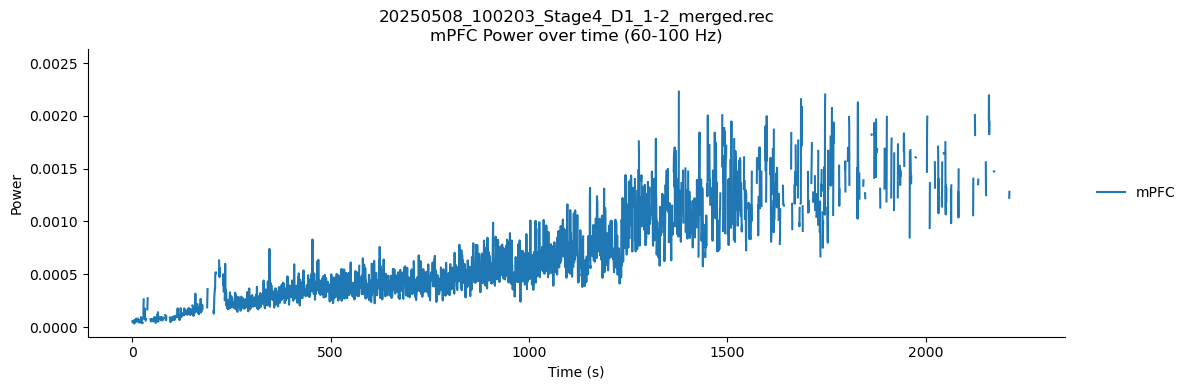

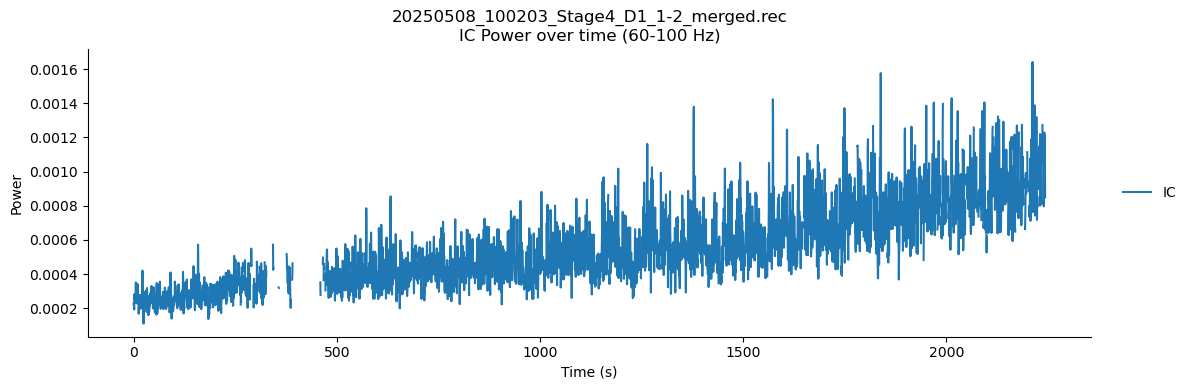

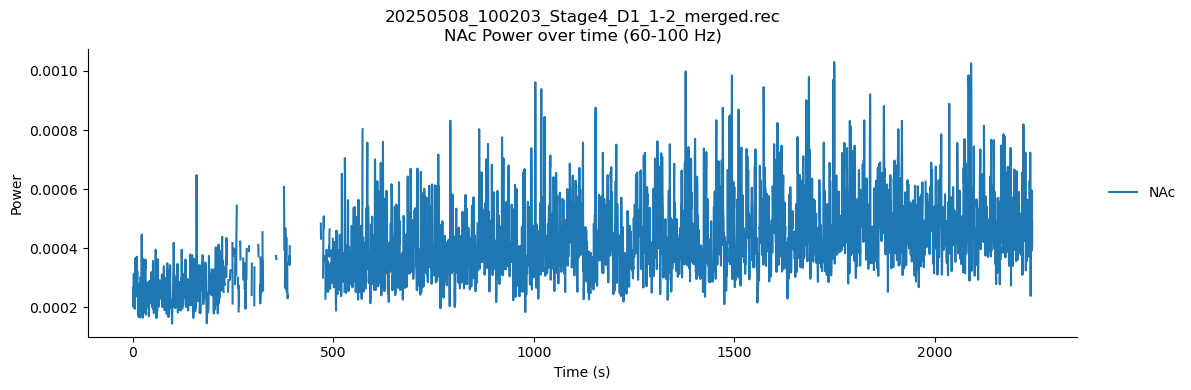

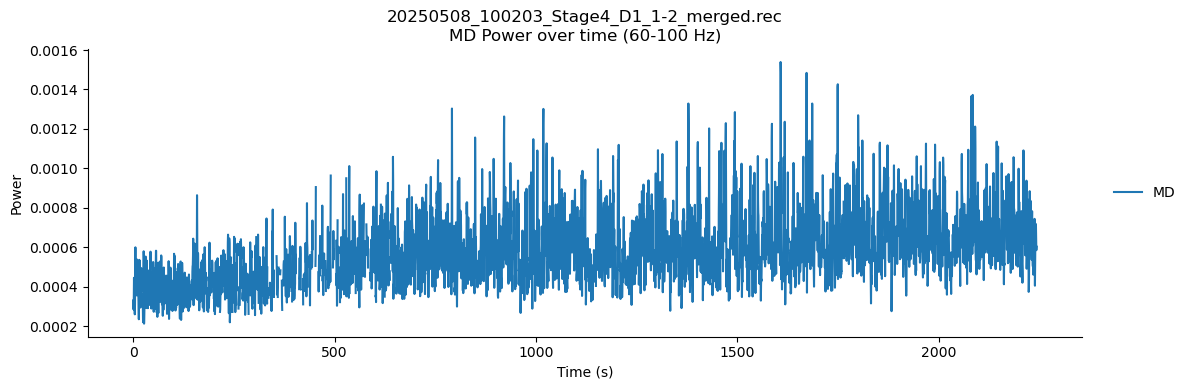

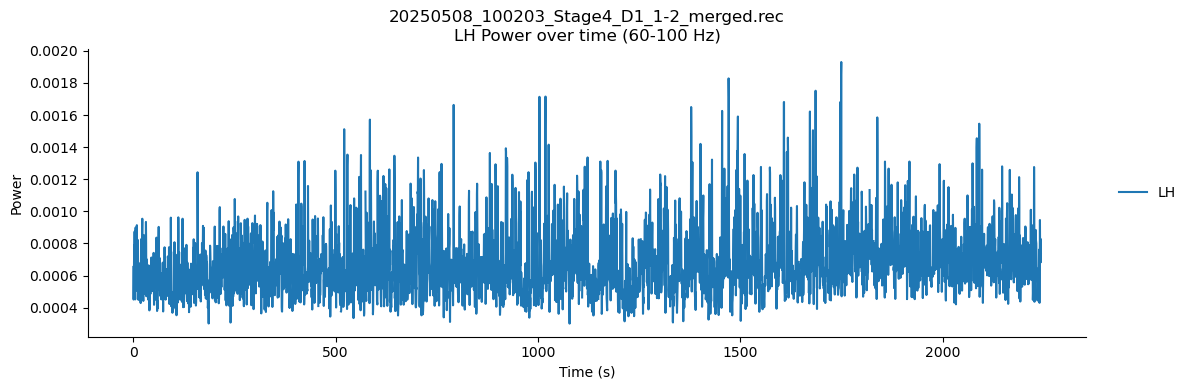

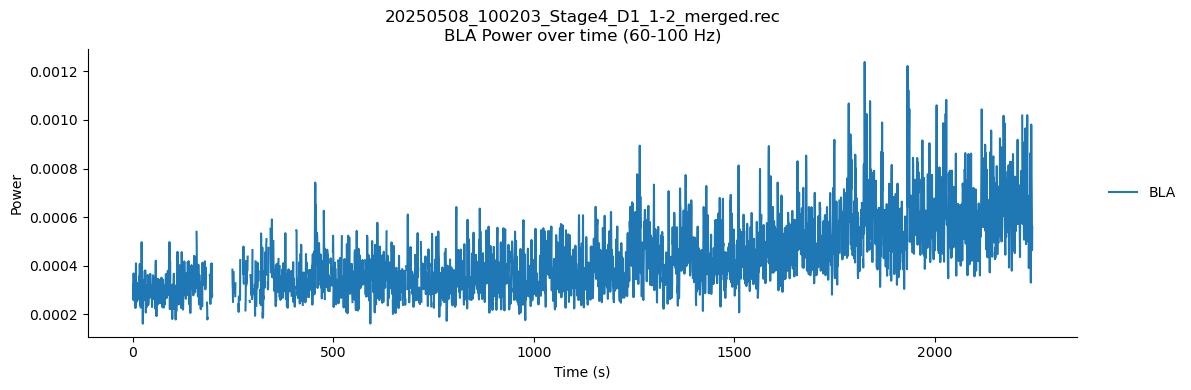

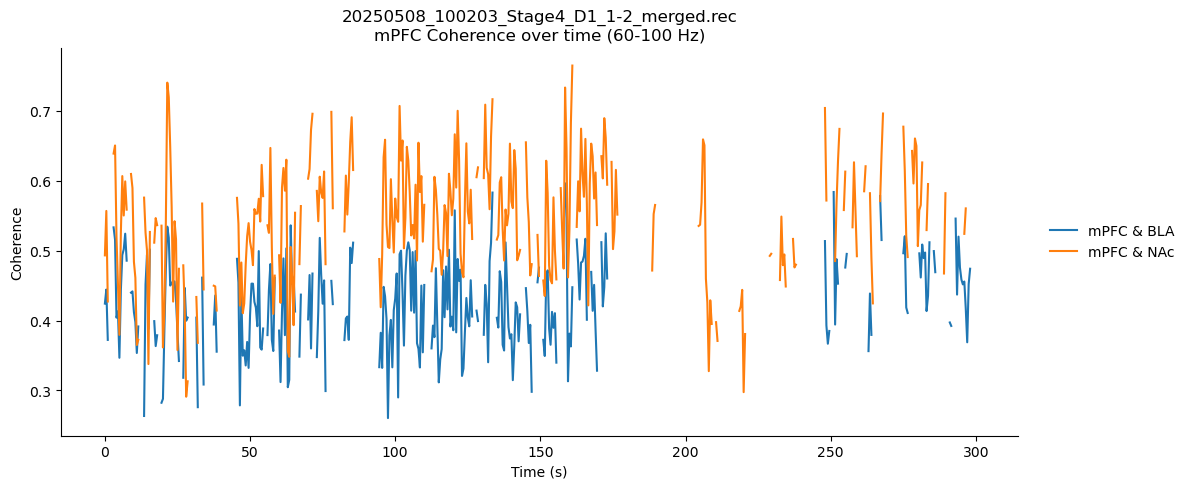

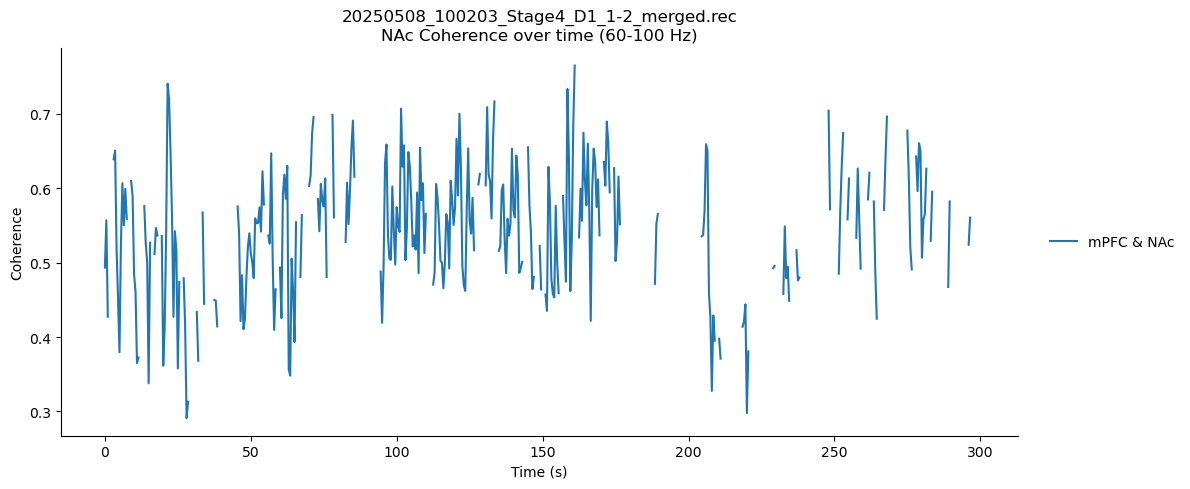

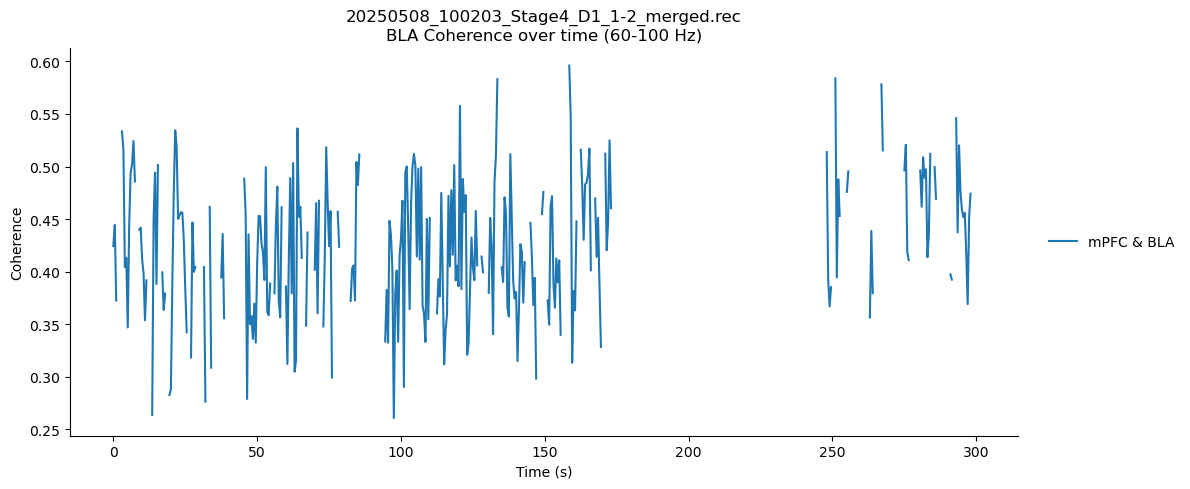

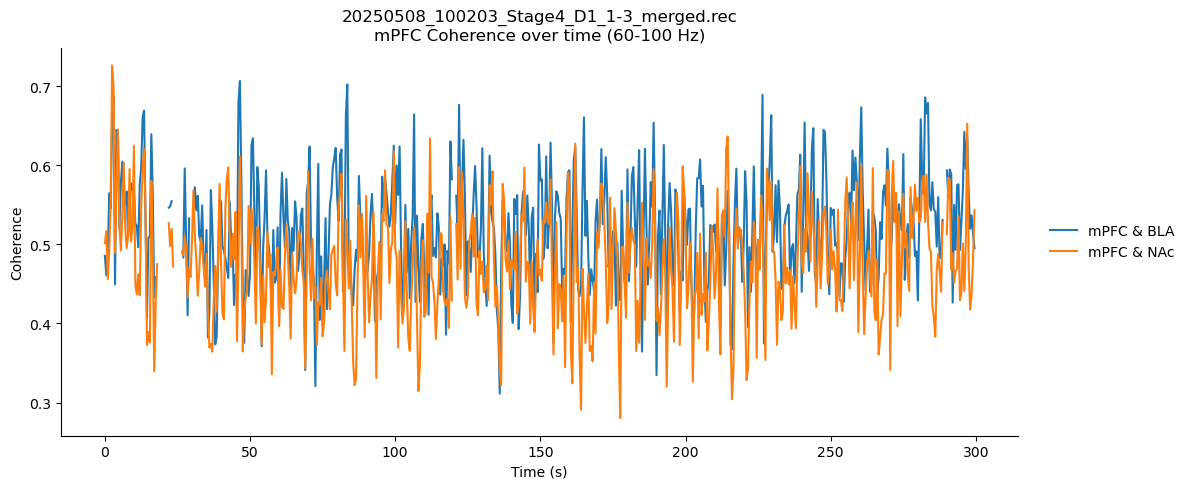

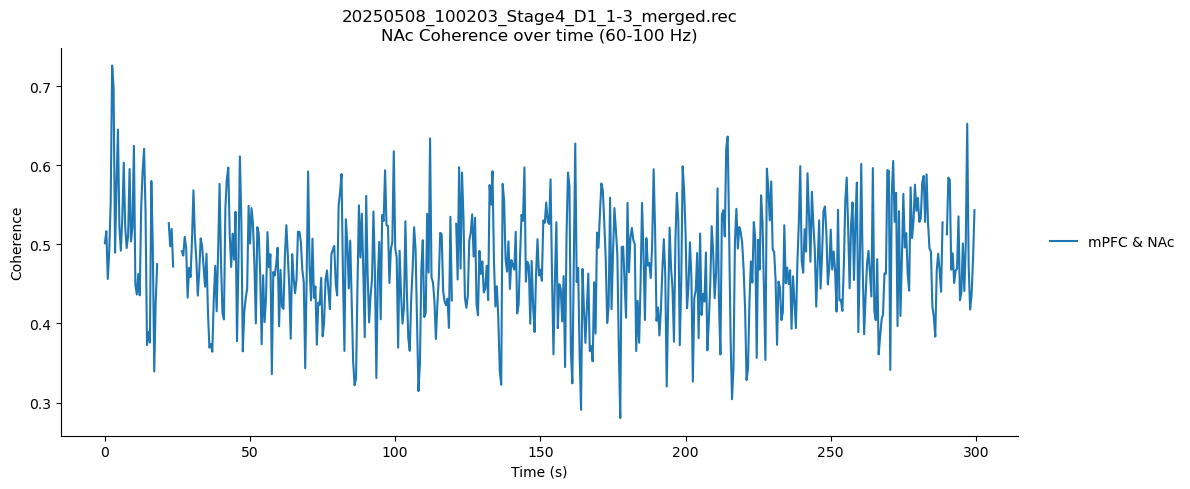

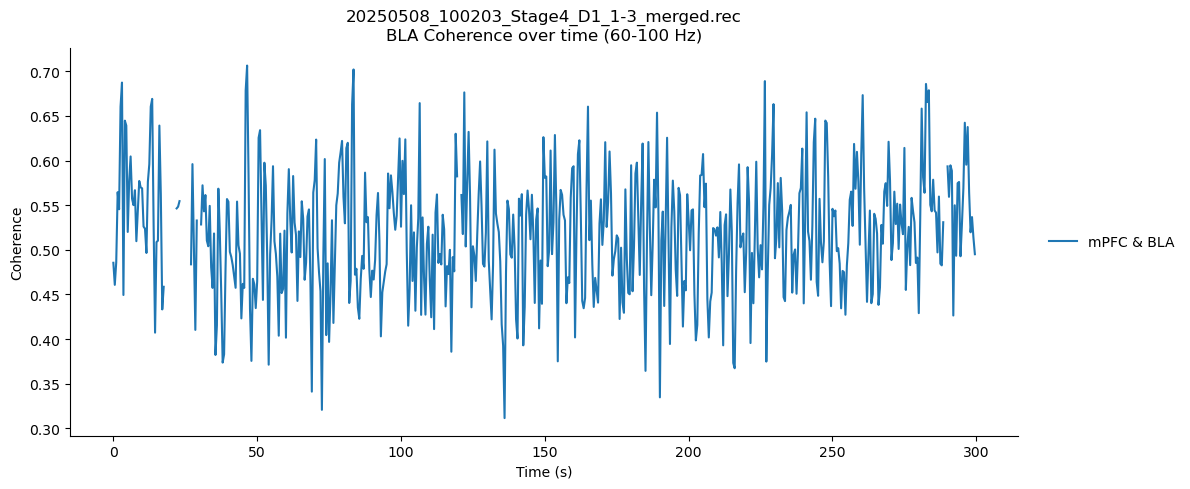

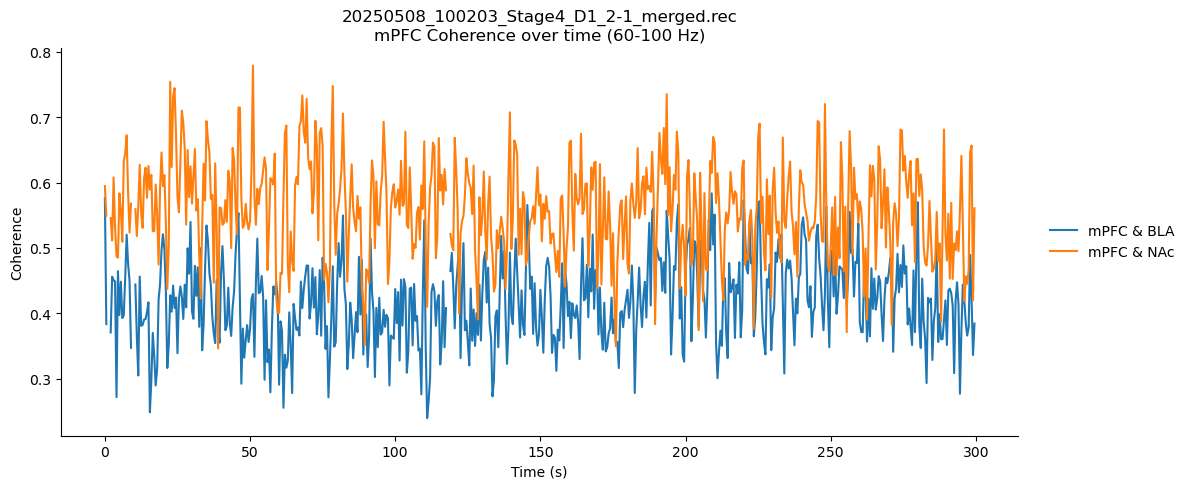

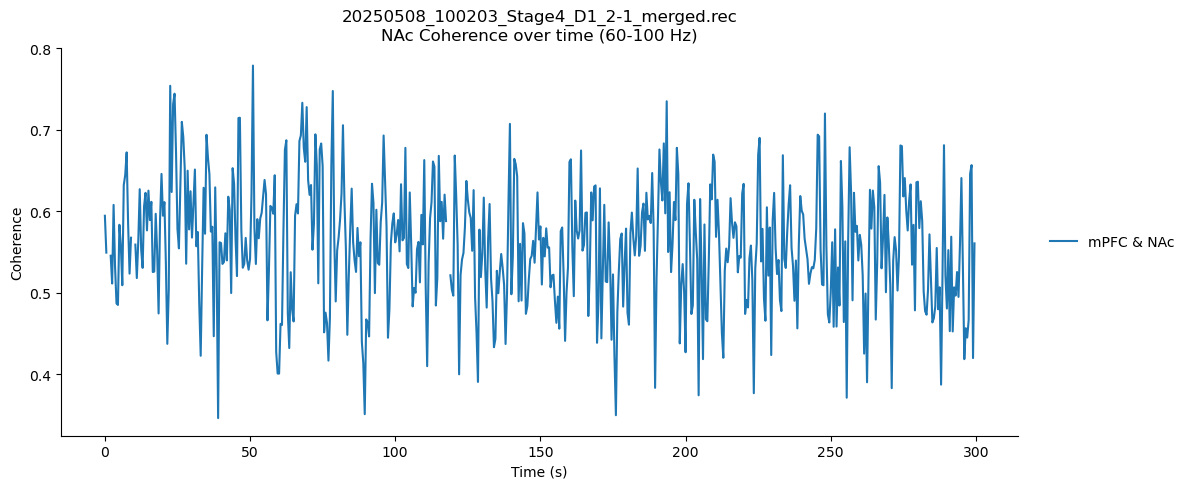

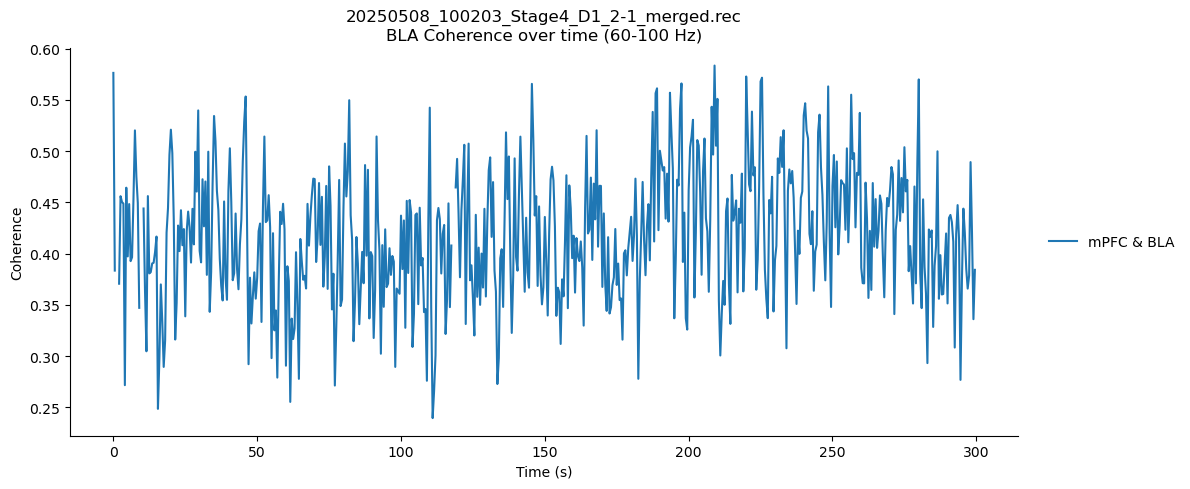

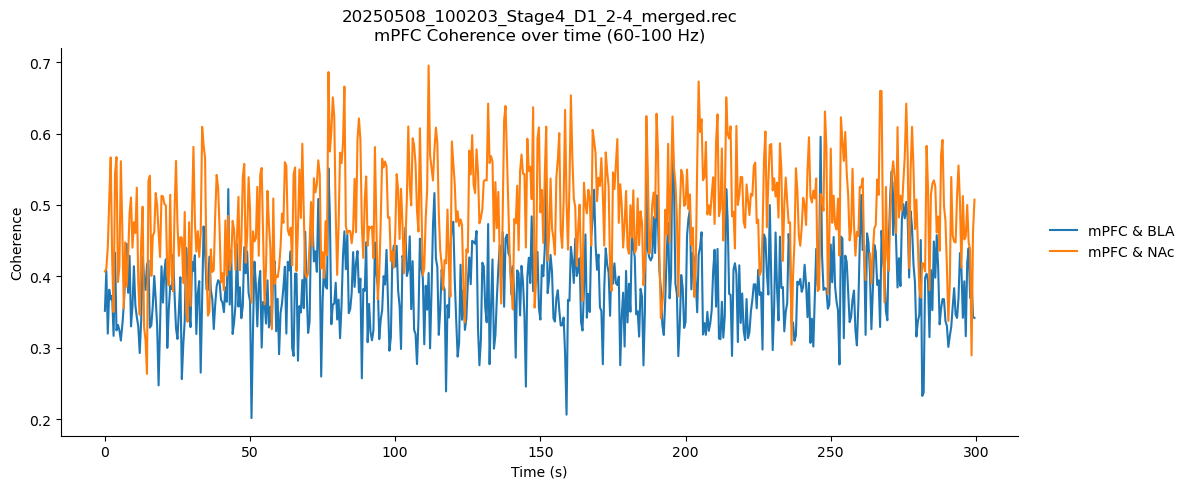

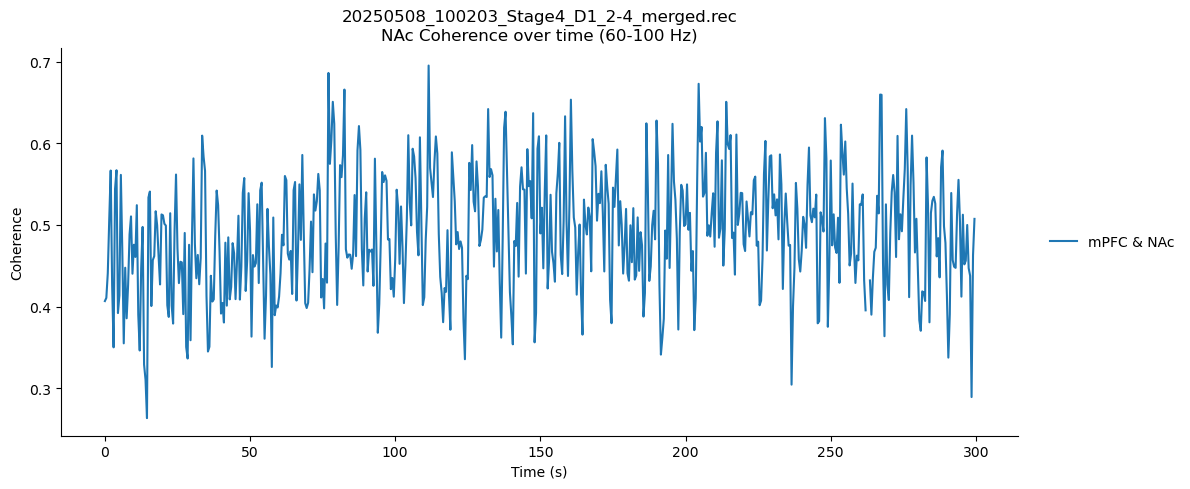

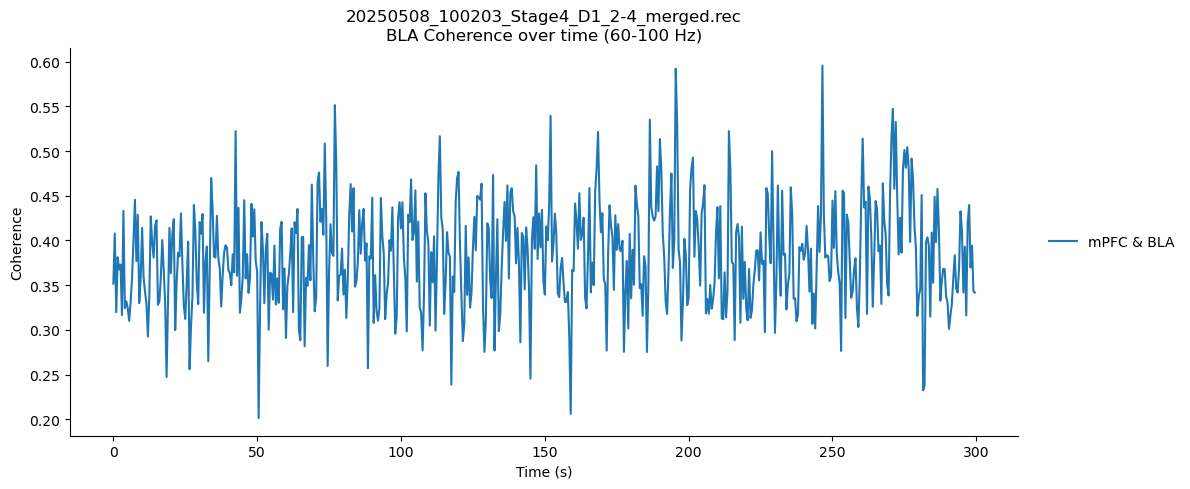

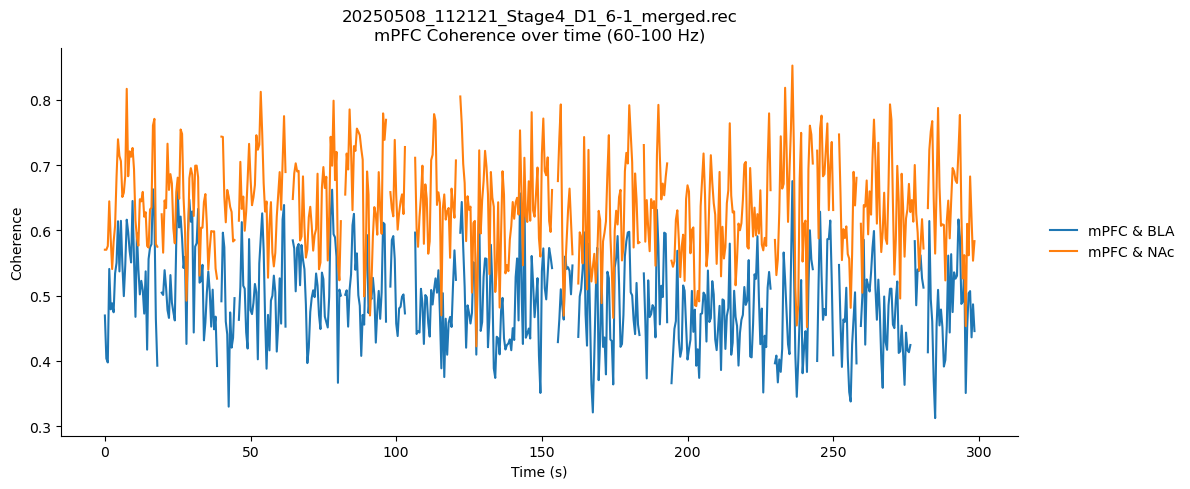

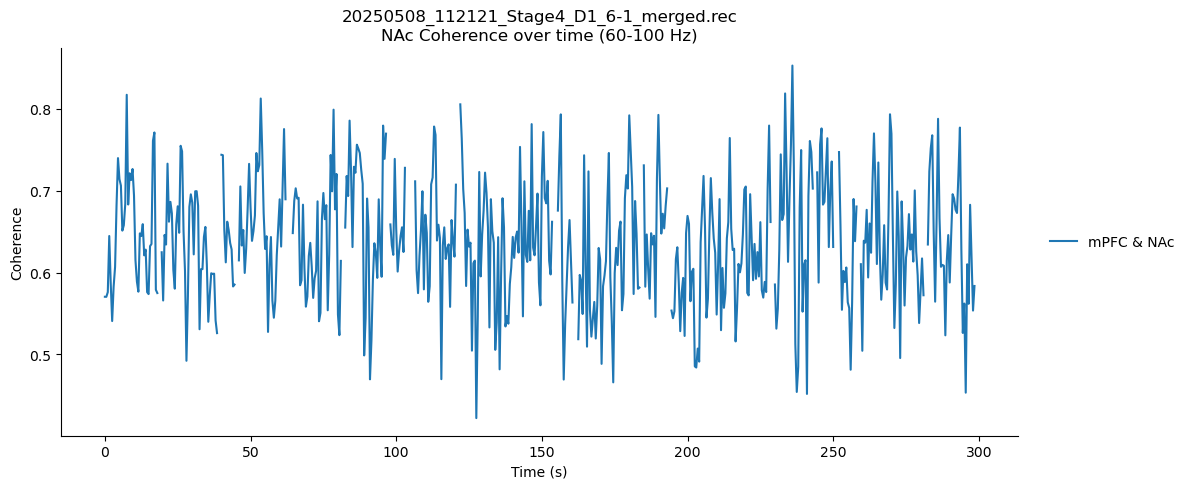

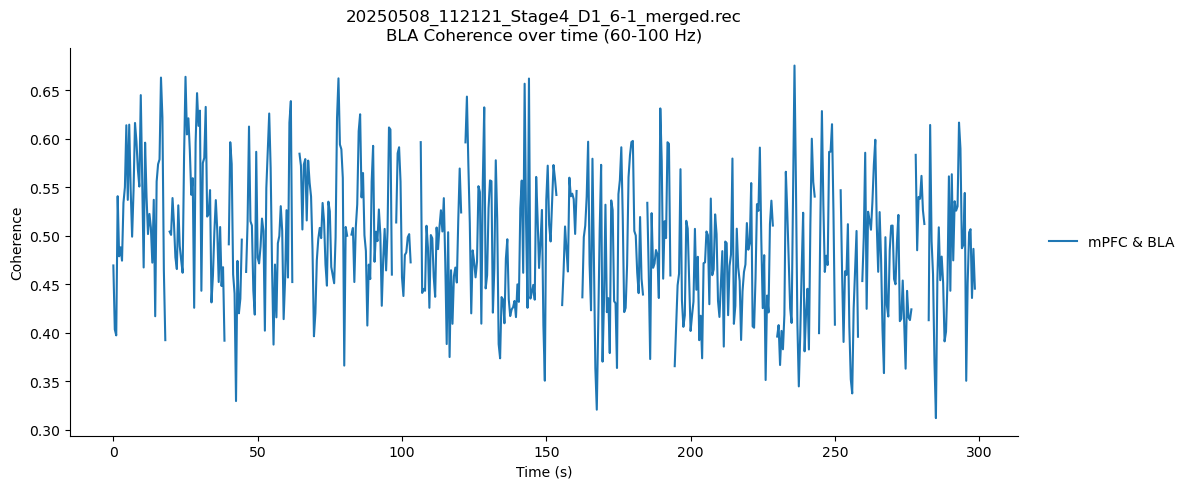

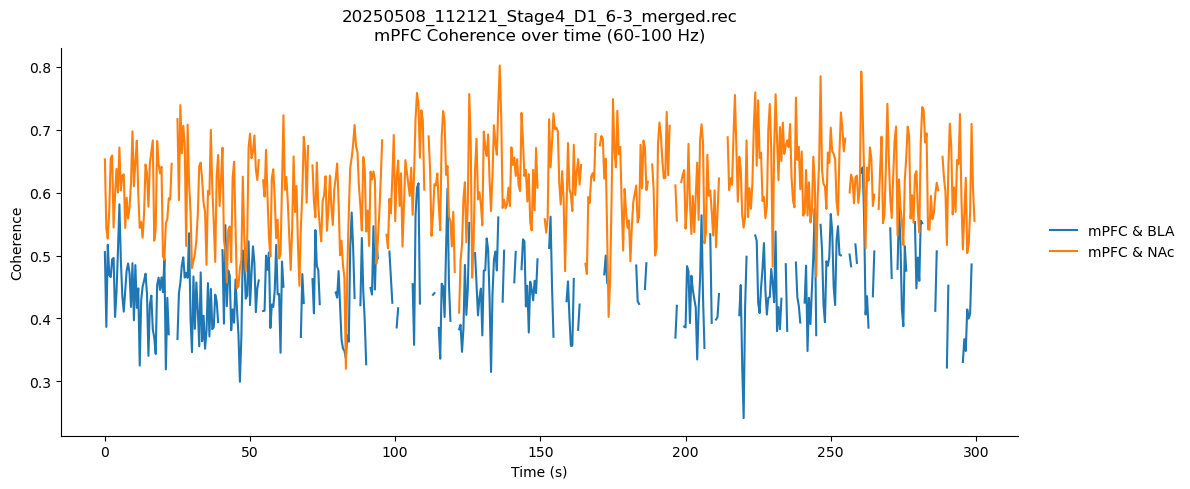

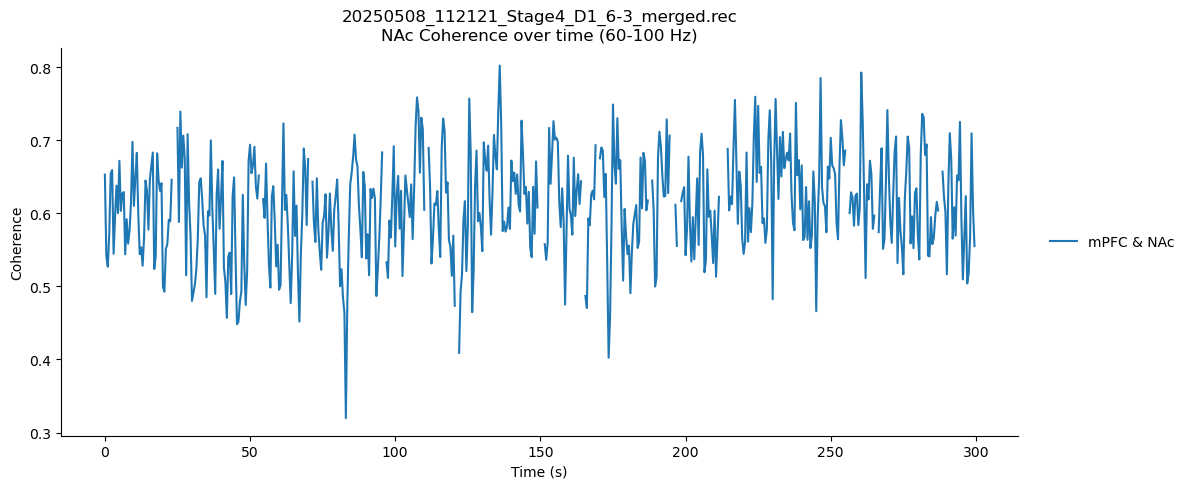

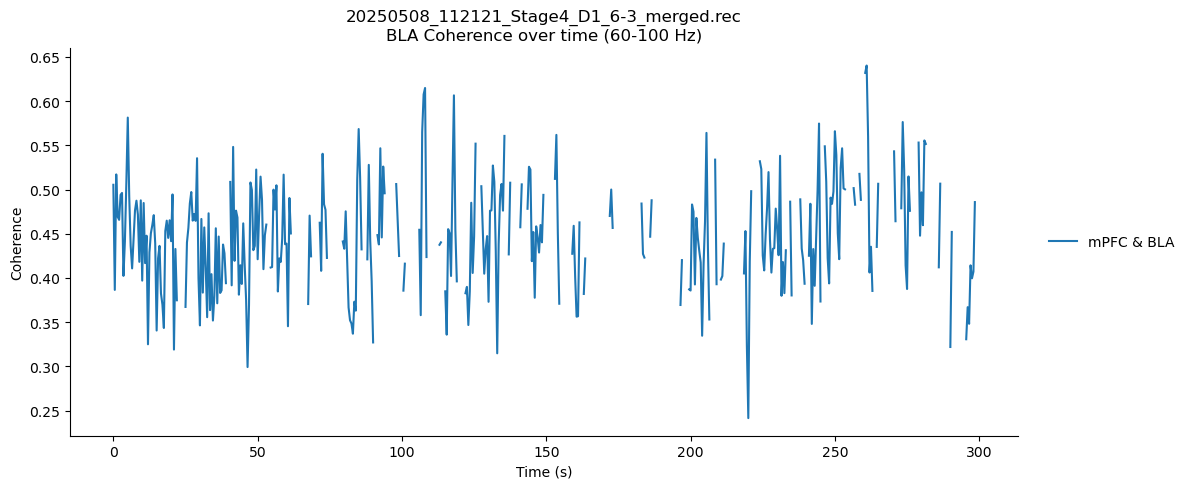

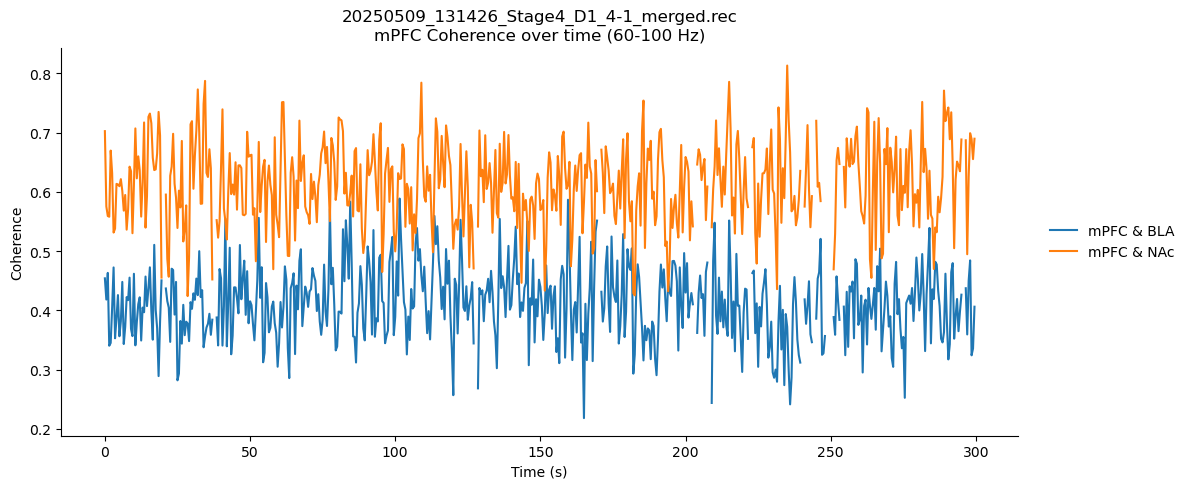

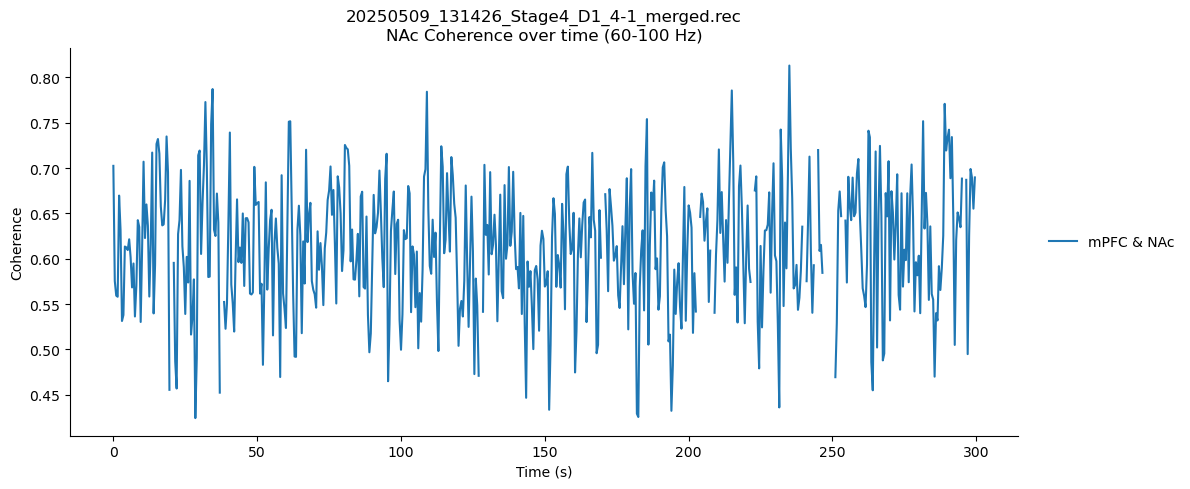

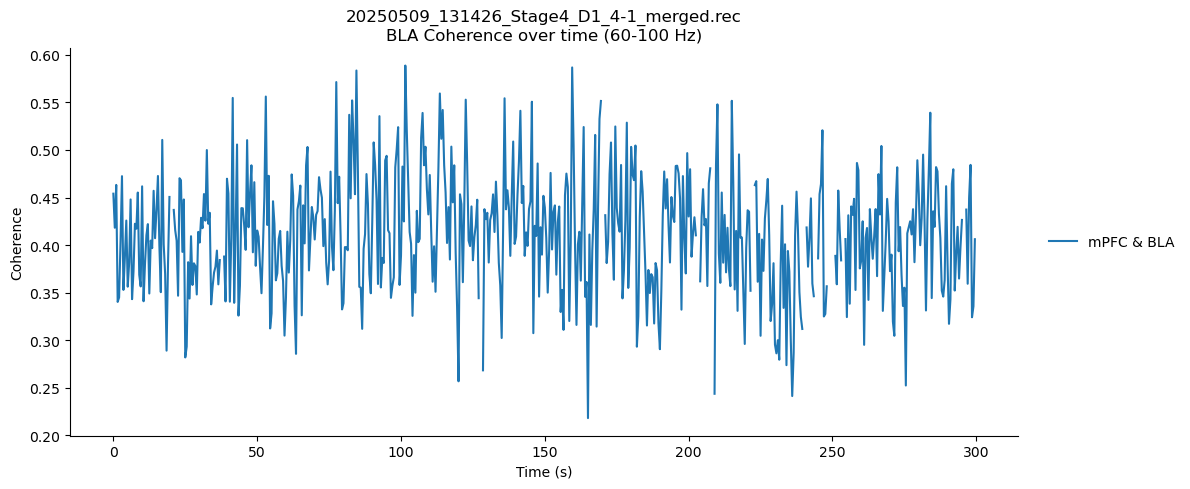

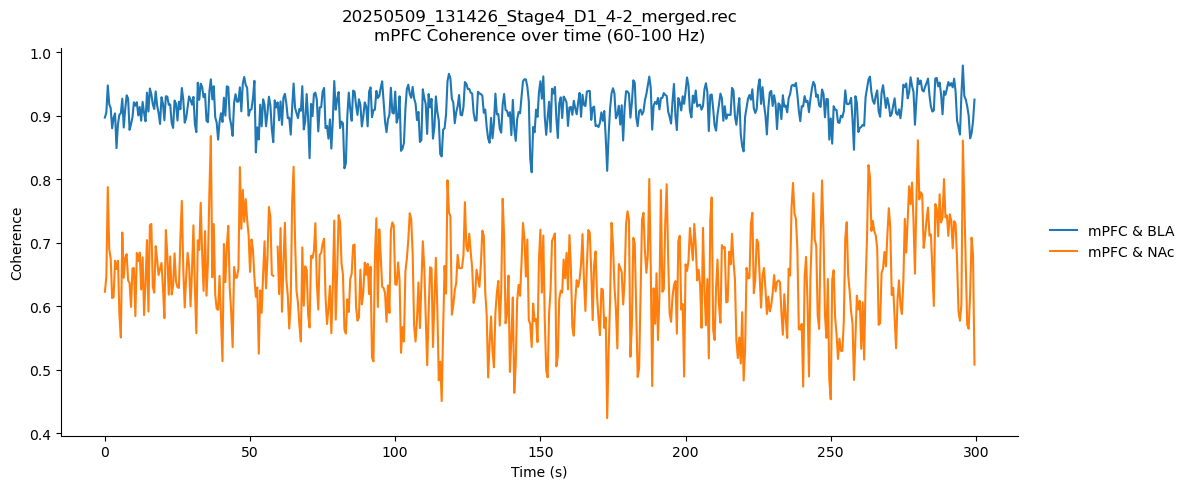

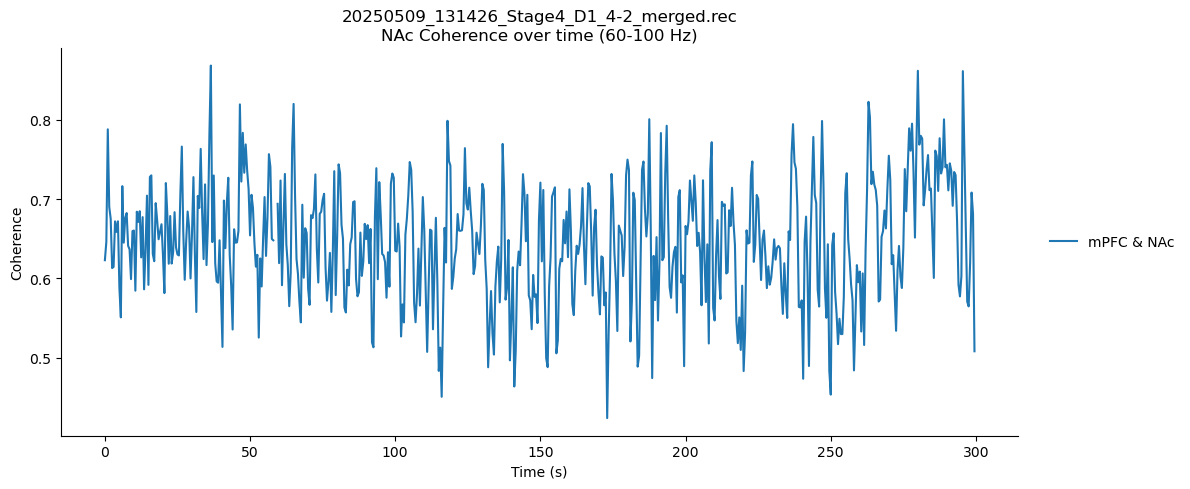

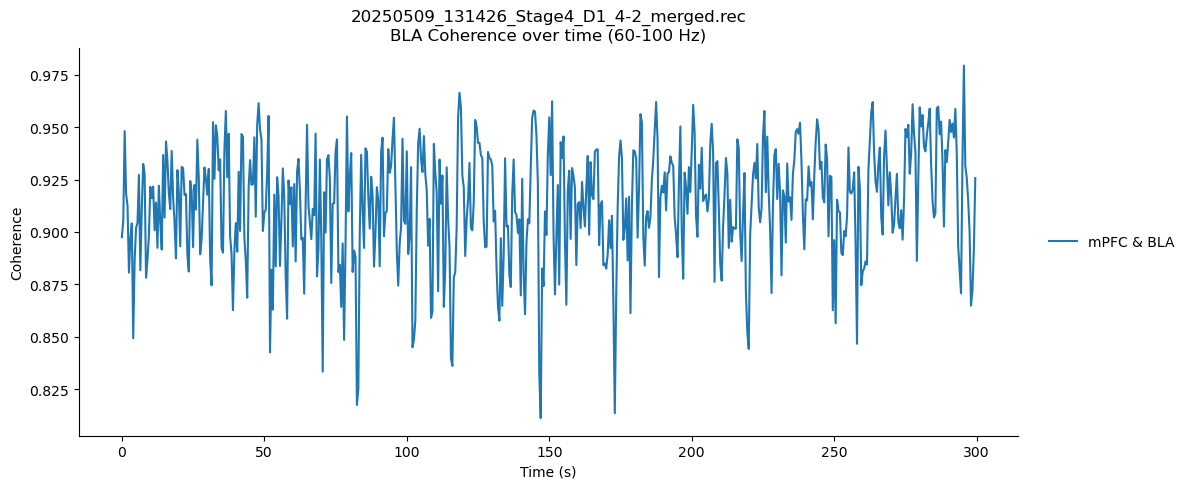

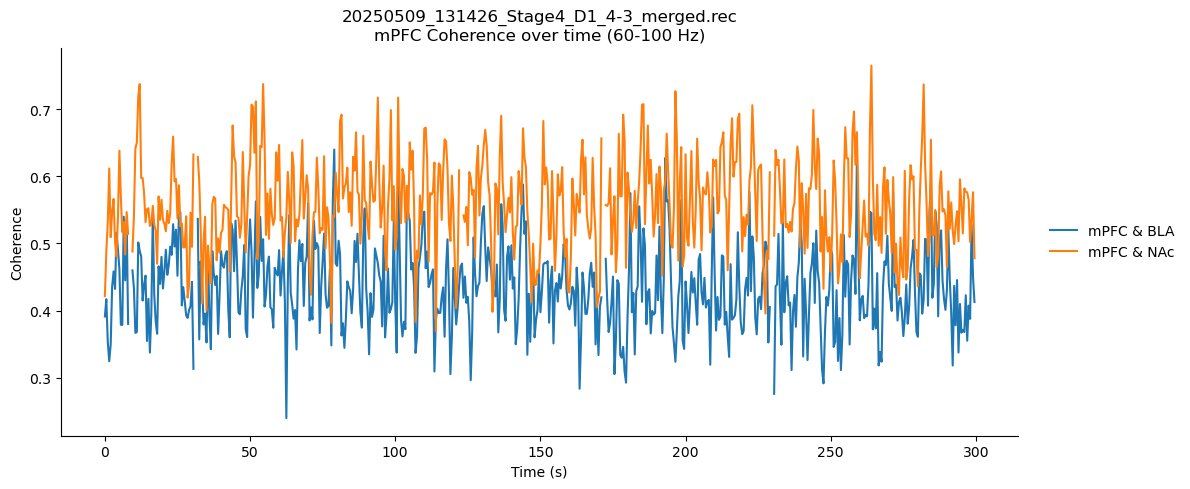

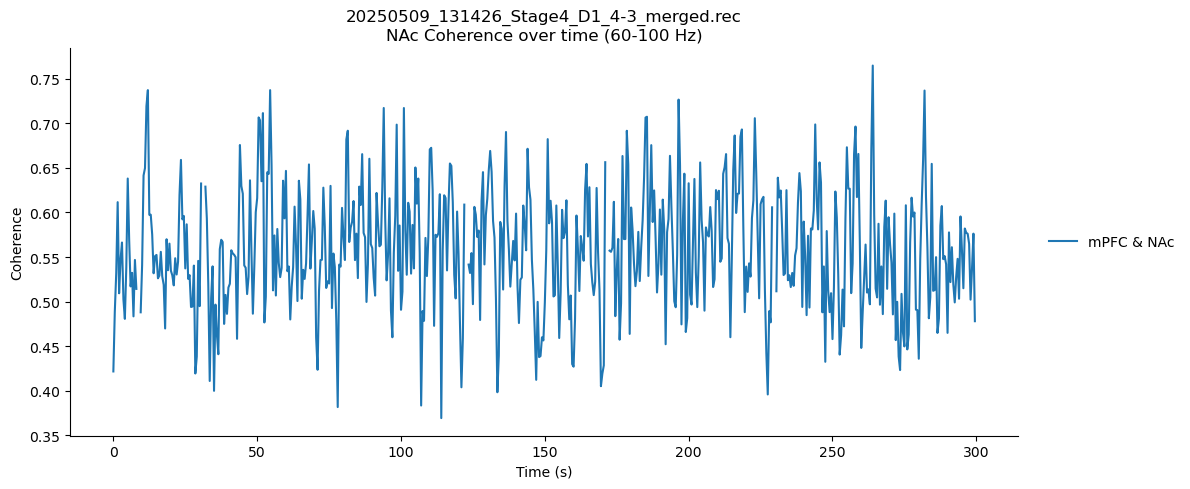

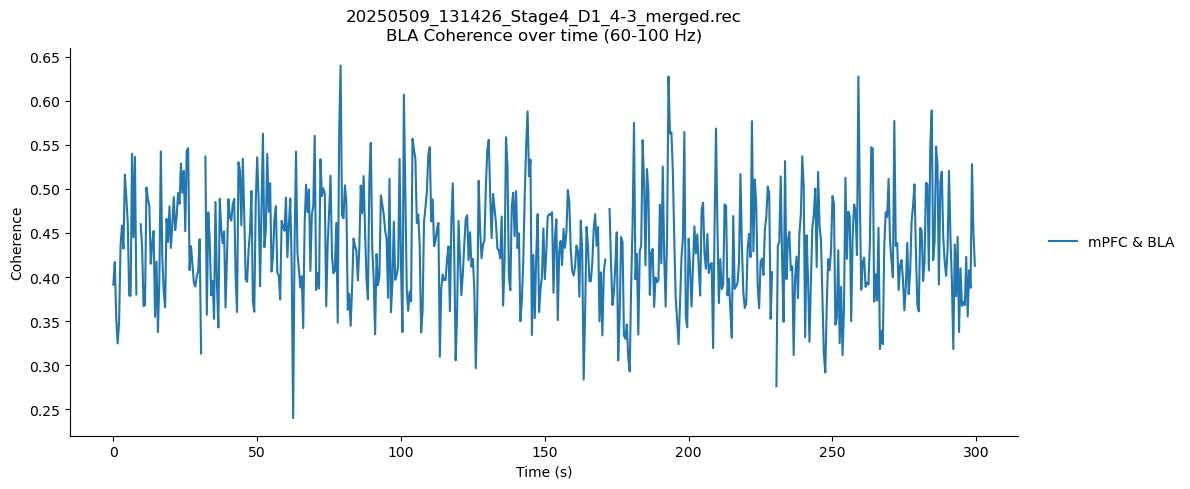

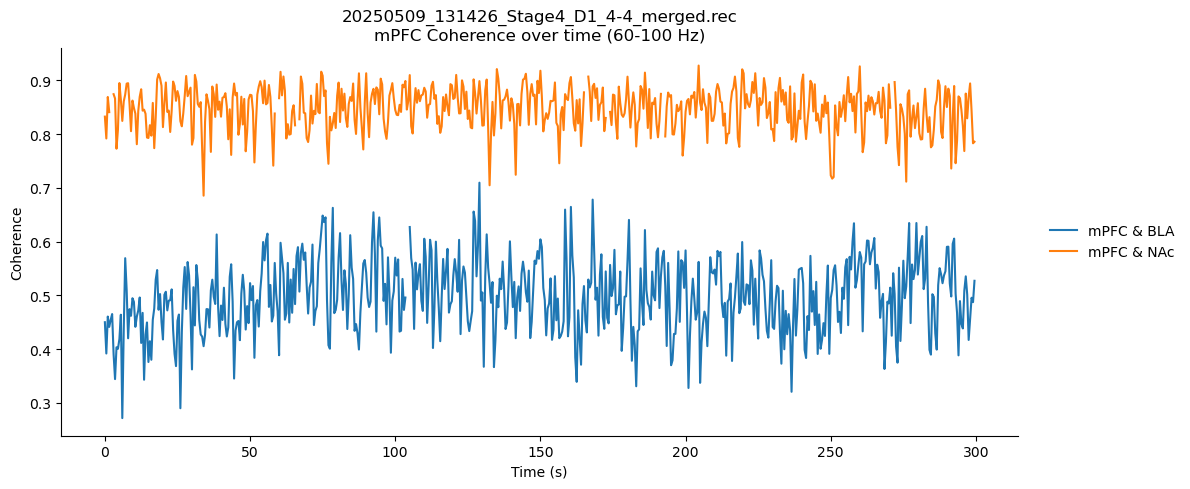

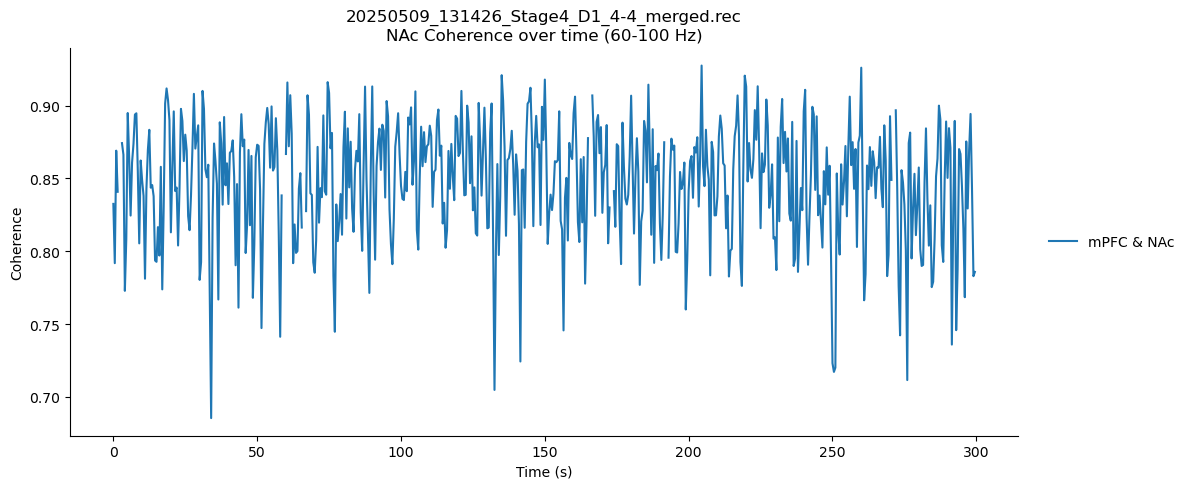

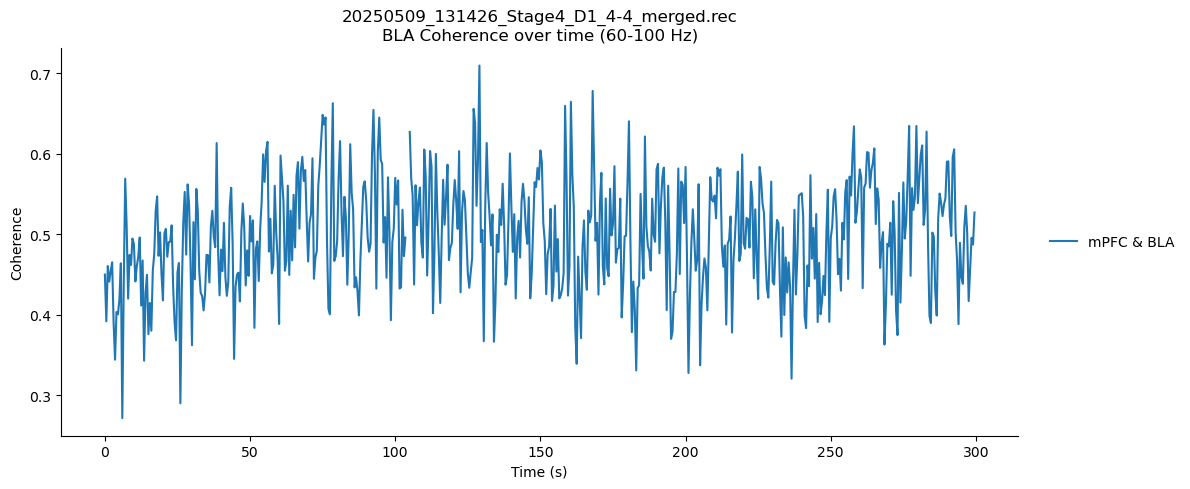

In [6]:
# Plot theta-band power across the full recording for one recording by name.
# This returns one axis per selected region.
plot_recording_spectral_traces(
    collection,
    recording="20250508_100203_Stage4_D1_1-2_merged.rec",
    mode="power",
    freq_range=(60, 100),
)

# Plot coherence for selected pairs in the first 5 minutes of every recording.
# This returns separate region-specific plots for each recording.
plot_collection_spectral_traces(
    collection,
    mode="coherence",
    time_window=(0, 300),
    freq_range=(60, 100),
    pairs=[("mPFC", "BLA"), ("mPFC", "NAc")],
)

# Plot a small number of incoming Granger traces per target region.
# plot_recording_spectral_traces(
#     collection,
#     recording=collection.recordings[0],
#     mode="granger",
#     freq_range=(13, 30),
#     max_traces=8,
# )

In [7]:
# Buffered ITI windows are loaded from the processed behavior pickle below.

# Load Saved Behavioral Events Into the LFP Collection

Load the processed Day 1 behavior pickle created by `stage4_quality_control.ipynb`. The import helper matches behavior recording names to `.rec` names, converts all imported event windows from seconds to milliseconds, and merges them into both recording- and collection-level event dictionaries. This preserves the buffered `baseline iti Xs` windows without calculating them again.

In [8]:
# Event importing is provided by update_collection_events_from_behavior().

In [33]:
behavior_path = REPO_ROOT / "data" / "processed" / "stage4_thresholded" / "Stage4_D8.pkl"
d8_behaviors = load_pickle(behavior_path)
print(f"Loaded {len(d8_behaviors)} processed Day 8 behavior recordings from {behavior_path}")

Loaded 10 processed Day 8 behavior recordings from C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\data\processed\stage4_thresholded\Stage4_D8.pkl


In [36]:
event_update_summary = update_collection_events_from_behavior(
    D8_collection,
    d8_behaviors,
    source_unit="seconds",
    strict=True,
)

NameError: name 'D8_collection' is not defined

In [11]:
print("Updated recordings:", len(event_update_summary["updated_recordings"]))
print("Unused behavior recordings:", event_update_summary["unused_behavior_recordings"])
event_update_summary["imported_events"]

Updated recordings: 10
Unused behavior recordings: []


{'20250508_100203_Stage4_D1_1-2_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250508_100203_Stage4_D1_1-3_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250508_100203_Stage4_D1_2-1_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250508_100203_Stage4_D1_2-4_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250508_112121_Stage4_D1_6-1_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250508_112121_Stage4_D1_6-

In [12]:
# Confirm that the saved two-second ITI windows are now stored in milliseconds.
recording = next(
    rec
    for rec in collection.recordings
    if rec.name == "20250508_100203_Stage4_D1_1-2_merged.rec"
)
baseline_windows_ms = np.asarray(recording.event_dict["baseline iti 2s"], dtype=float)
baseline_durations_ms = baseline_windows_ms[:, 1] - baseline_windows_ms[:, 0]
print(baseline_windows_ms[:5])
print("window count:", len(baseline_windows_ms))
print(
    "duration min/max (ms):",
    np.nanmin(baseline_durations_ms),
    np.nanmax(baseline_durations_ms),
)

[[    0.  2000.]
 [ 2000.  4000.]
 [ 4000.  6000.]
 [ 6000.  8000.]
 [ 8000. 10000.]]
window count: 142
duration min/max (ms): 2000.0 2000.0


# Event-Aligned Average Spectrograms

Average time-resolved spectral content across occurrences of an event. Events are aligned to onset, averaged within each recording, and then averaged across recordings so recordings with more events do not receive greater weight.


In [13]:
# The helper accepts the full collection and can optionally filter it with
# condition_recordings and selected_condition.


In [14]:
condition_dict = build_condition_dict(collection)

for condition, recording_names in condition_dict.items():
    print(f"{condition}: {len(recording_names)} recordings")
    for name in recording_names:
        print("  ", name)

subject with recipient: 4 recordings
   20250508_100203_Stage4_D1_1-2_merged.rec
   20250508_100203_Stage4_D1_2-4_merged.rec
   20250509_131426_Stage4_D1_4-3_merged.rec
   20250509_131426_Stage4_D1_4-4_merged.rec
recipient: 4 recordings
   20250508_100203_Stage4_D1_1-3_merged.rec
   20250508_100203_Stage4_D1_2-1_merged.rec
   20250509_131426_Stage4_D1_4-1_merged.rec
   20250509_131426_Stage4_D1_4-2_merged.rec
subject alone: 2 recordings
   20250508_112121_Stage4_D1_6-1_merged.rec
   20250508_112121_Stage4_D1_6-3_merged.rec


## Nosepoke
### High-Gamma Conditions D1

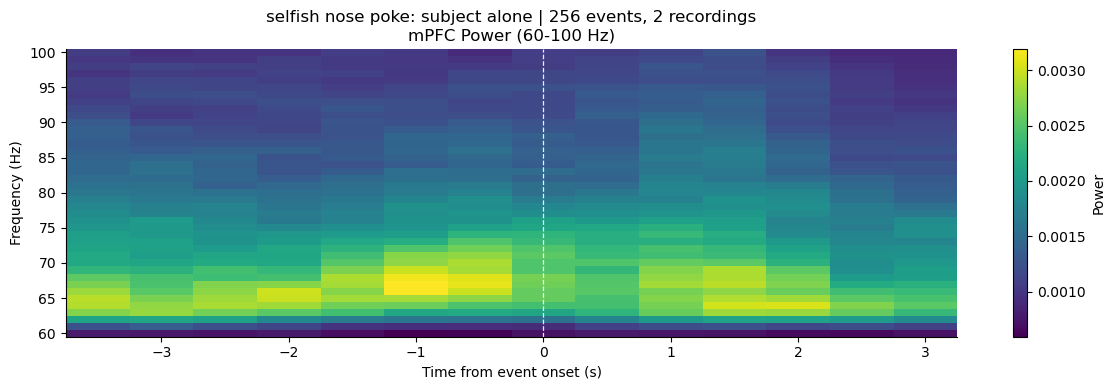

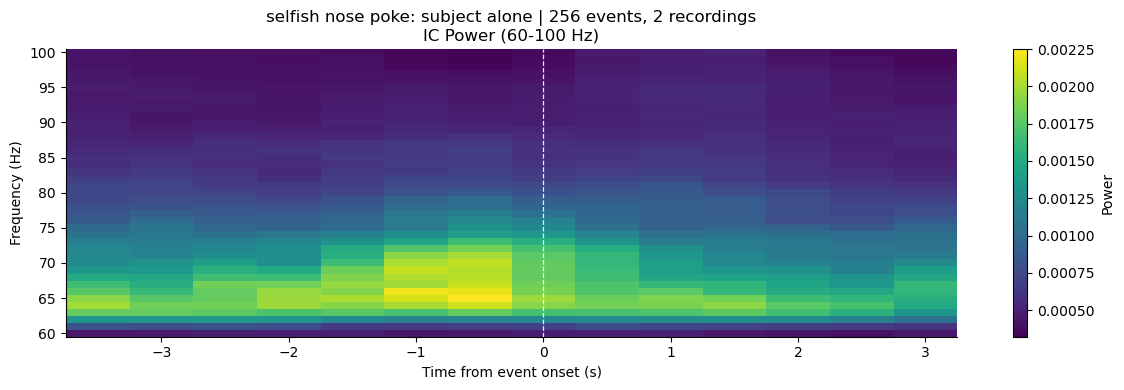

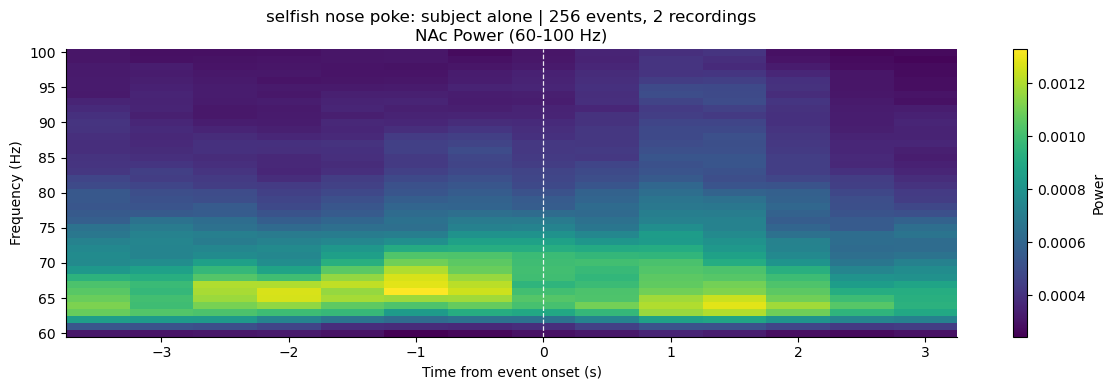

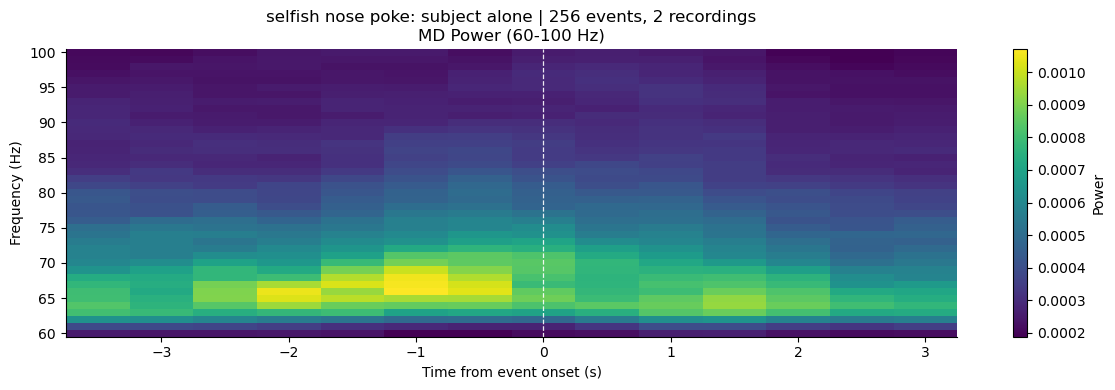

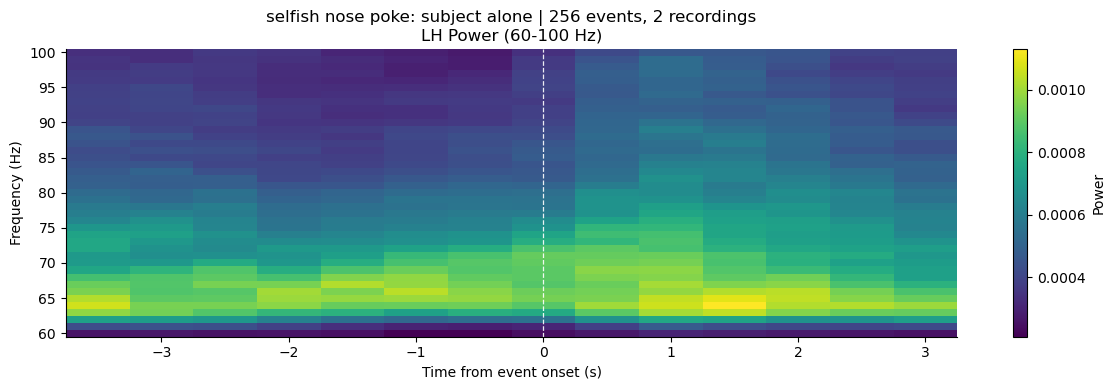

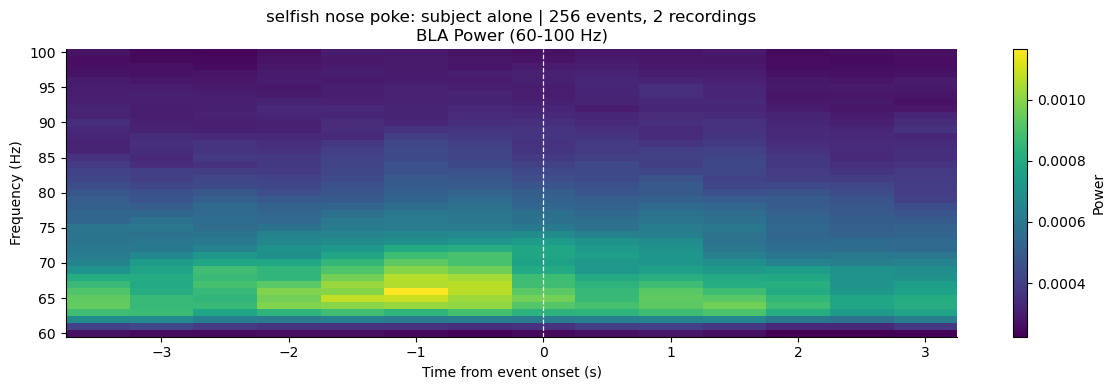

In [15]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    collection,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject alone",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

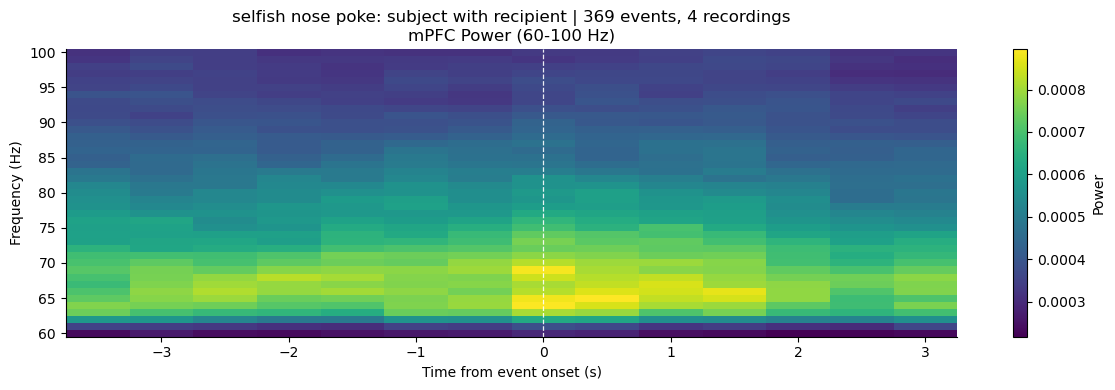

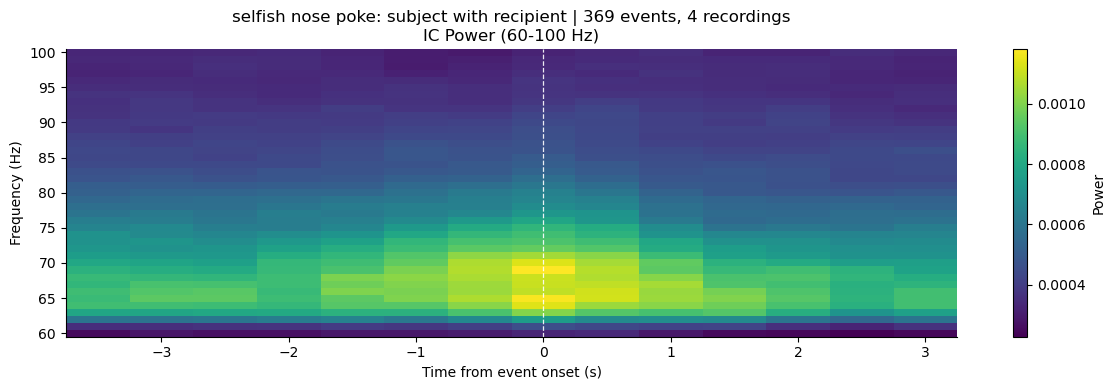

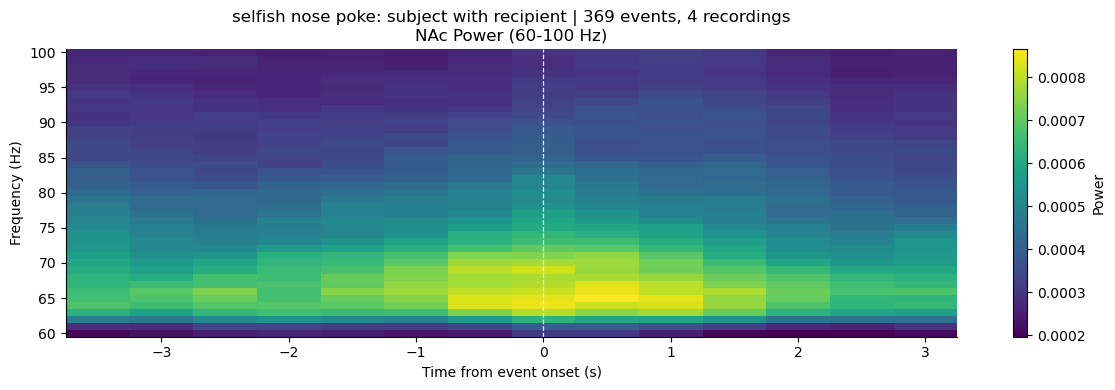

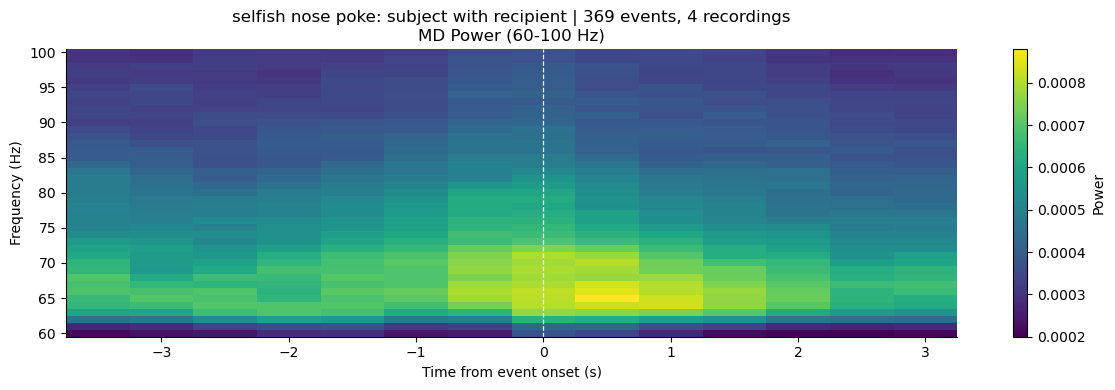

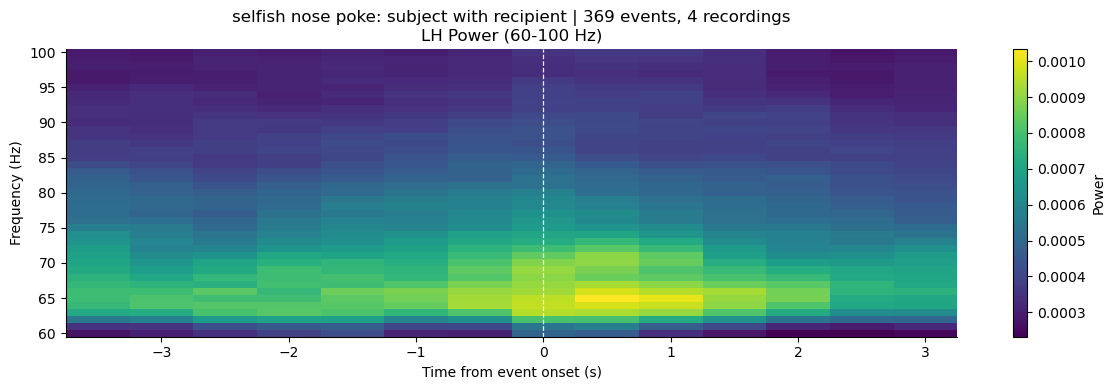

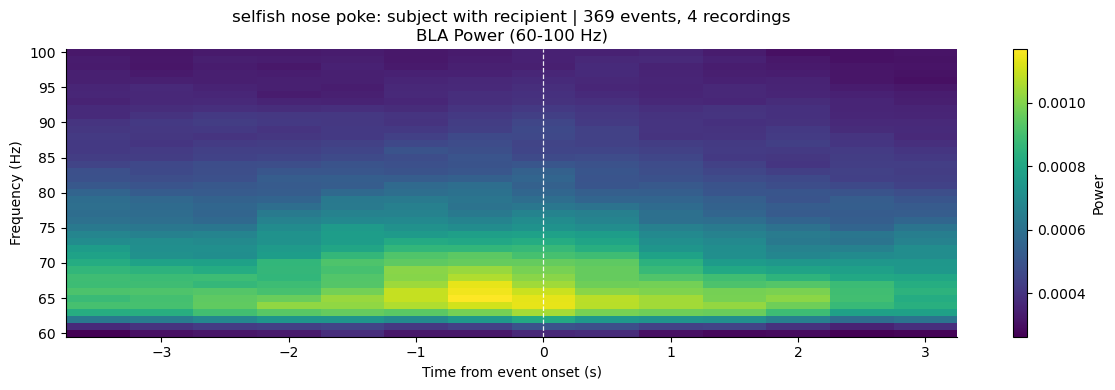

In [16]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    collection,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

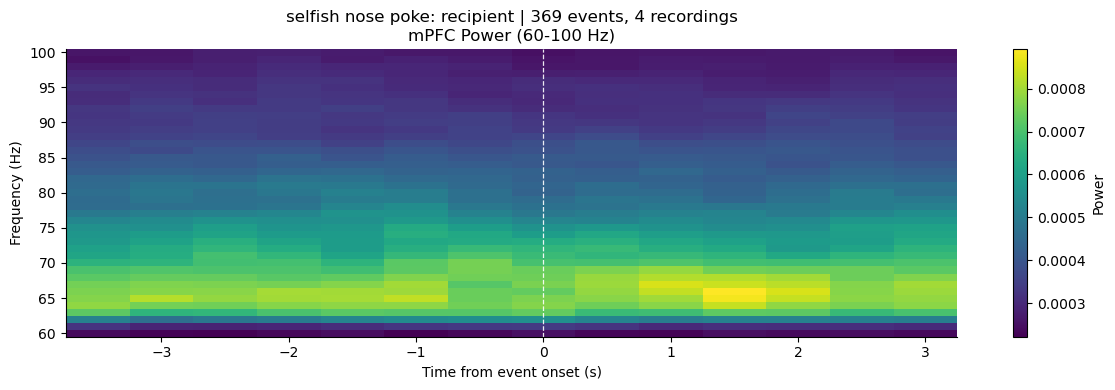

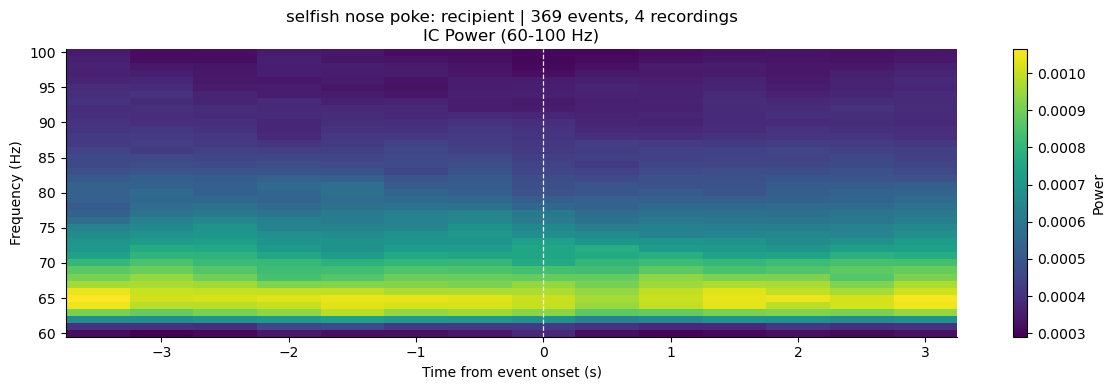

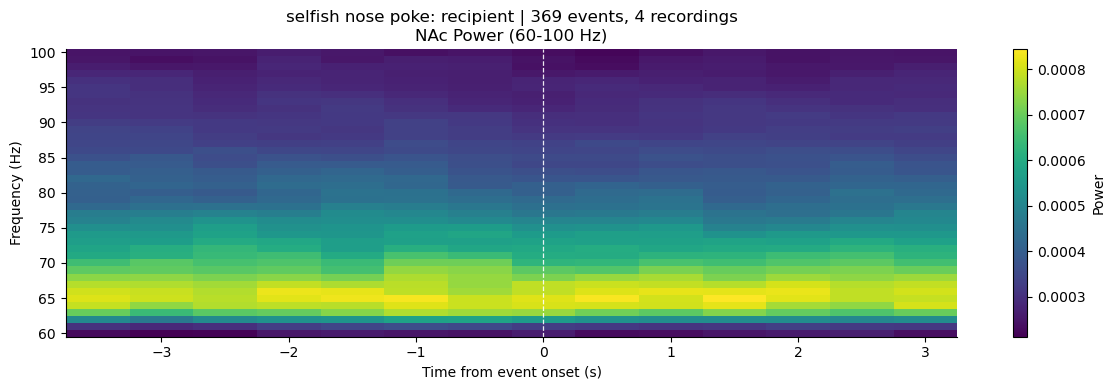

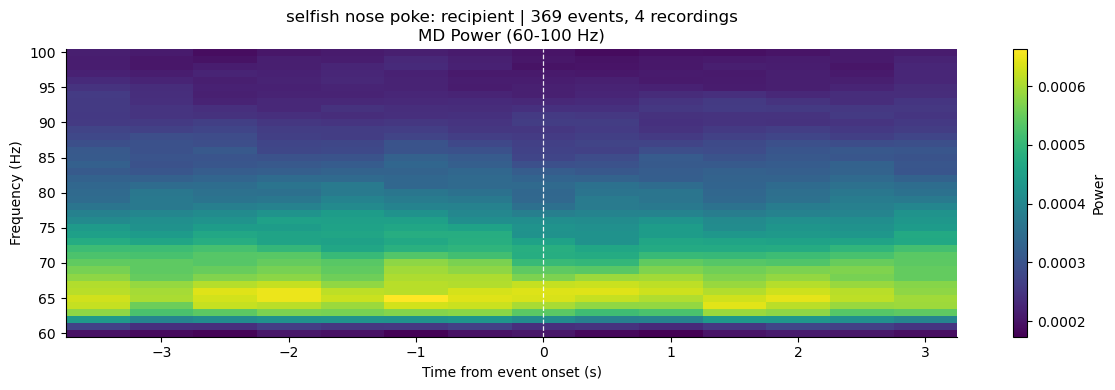

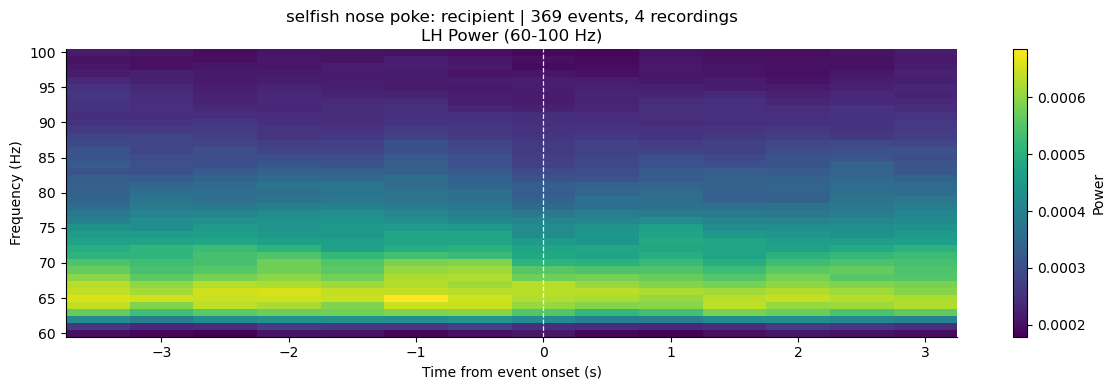

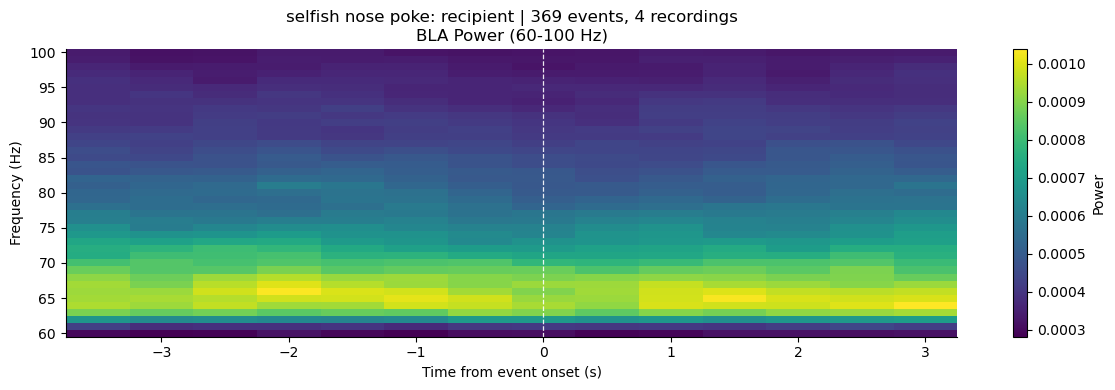

In [17]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    collection,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

### High-Gamma Social Choice D1

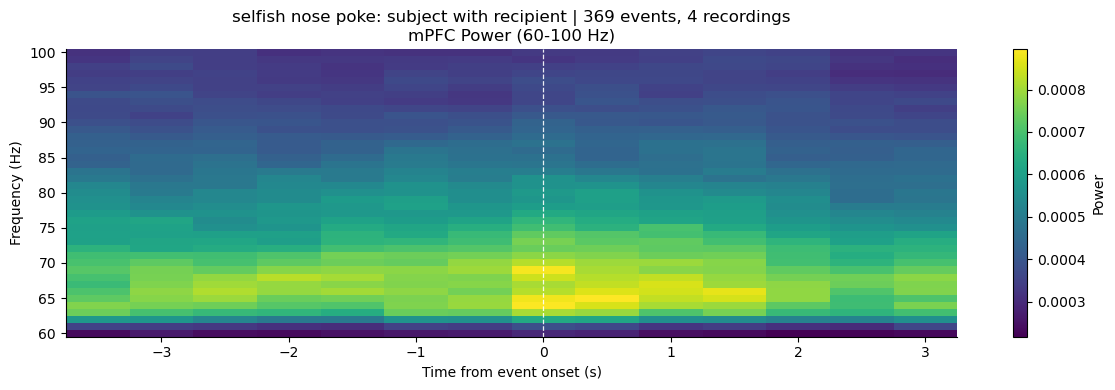

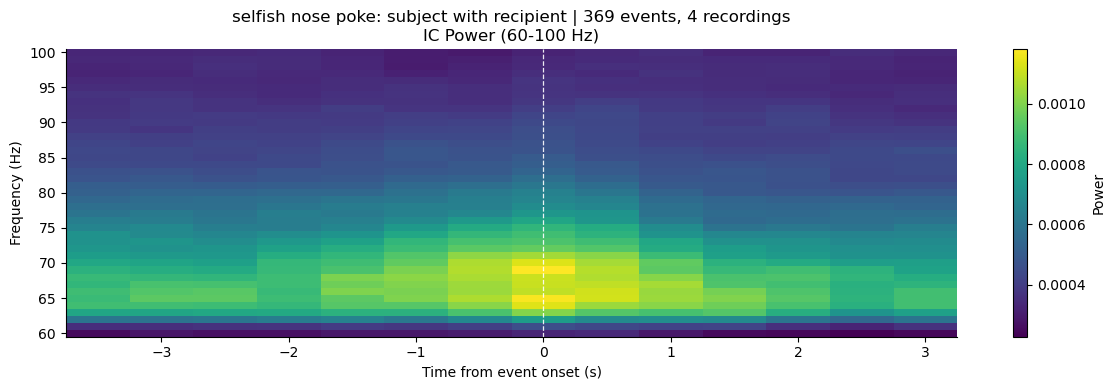

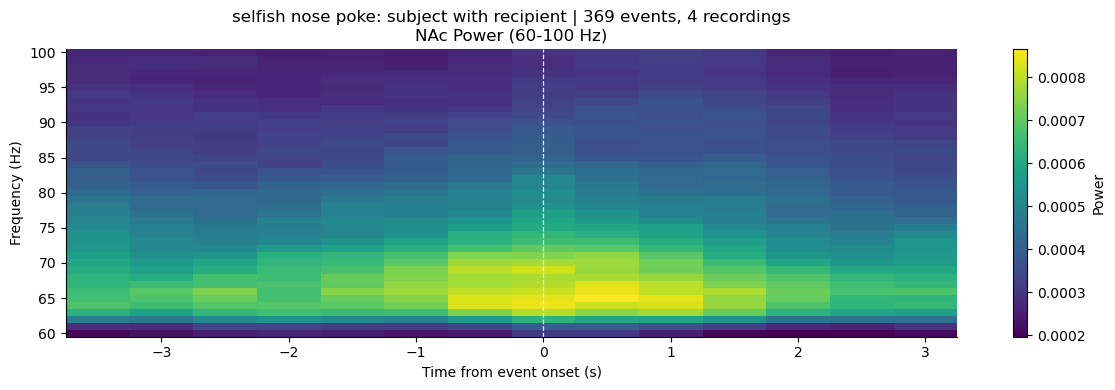

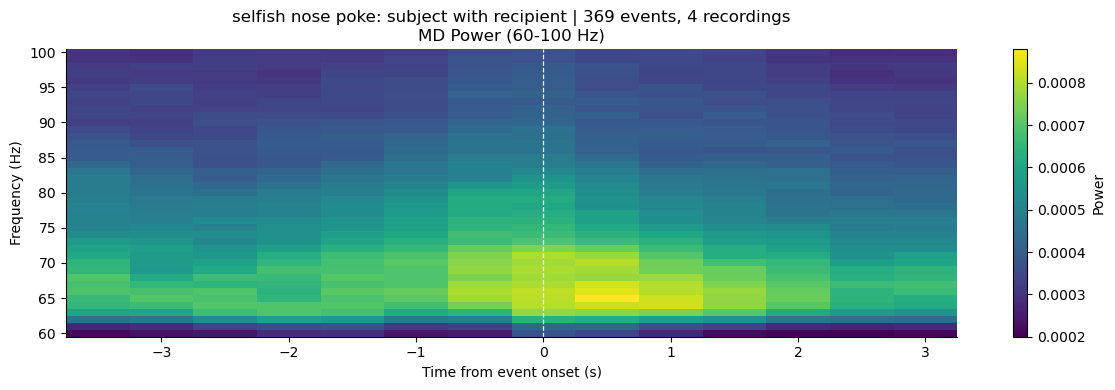

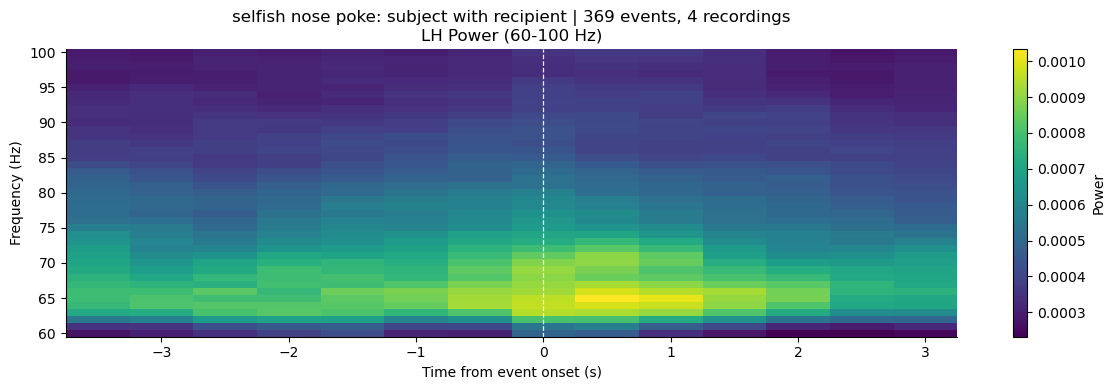

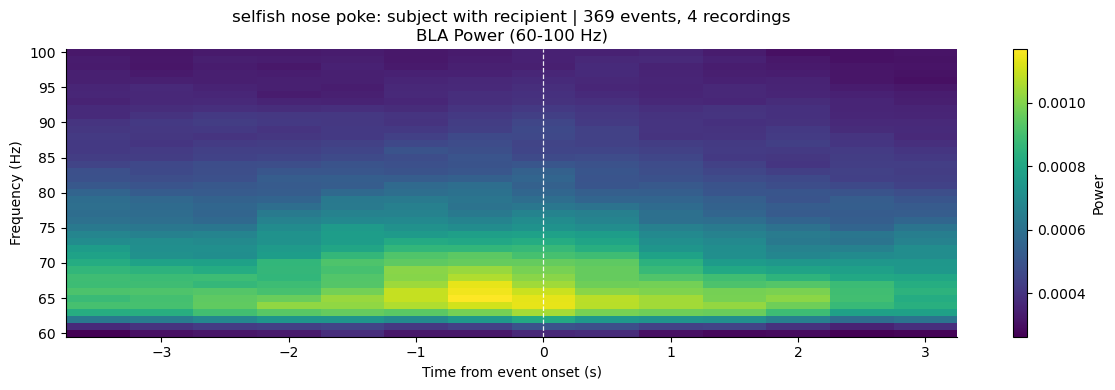

In [23]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    collection,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

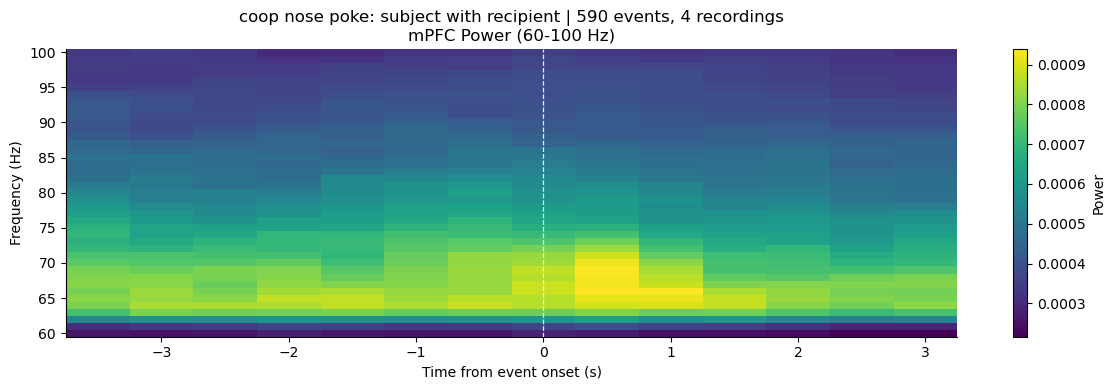

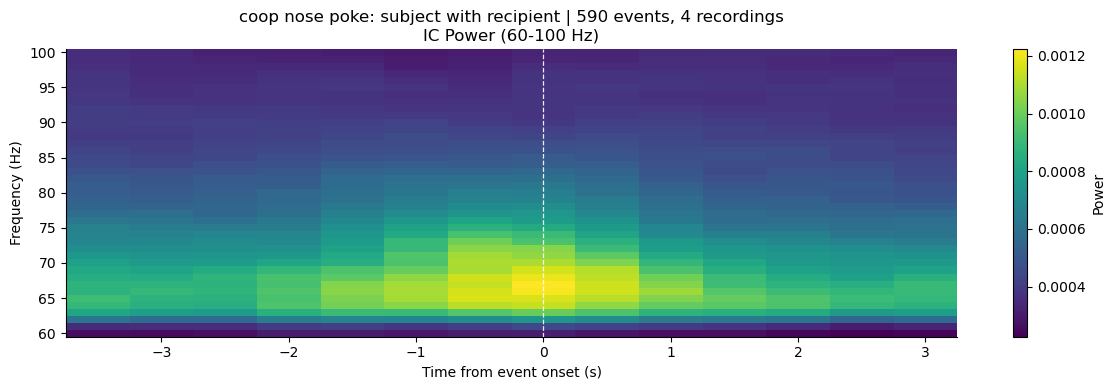

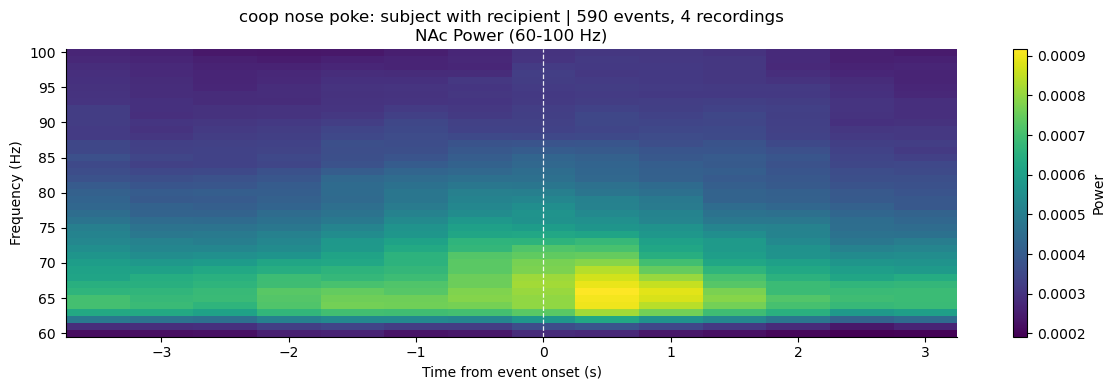

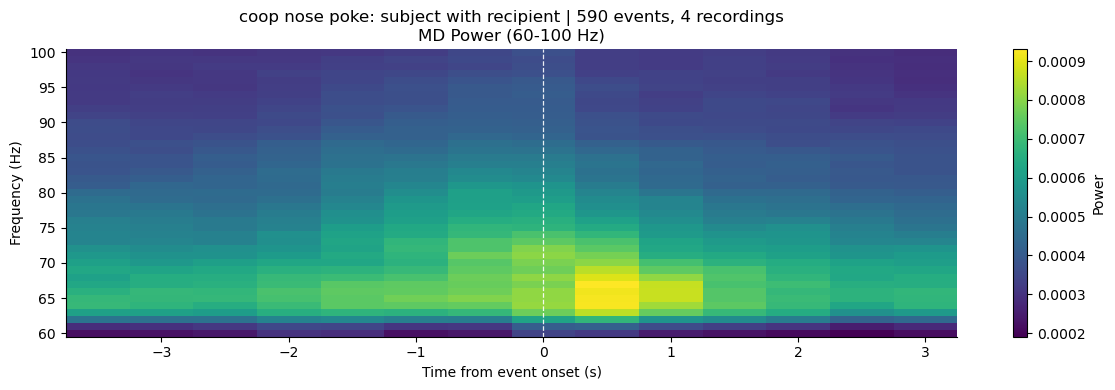

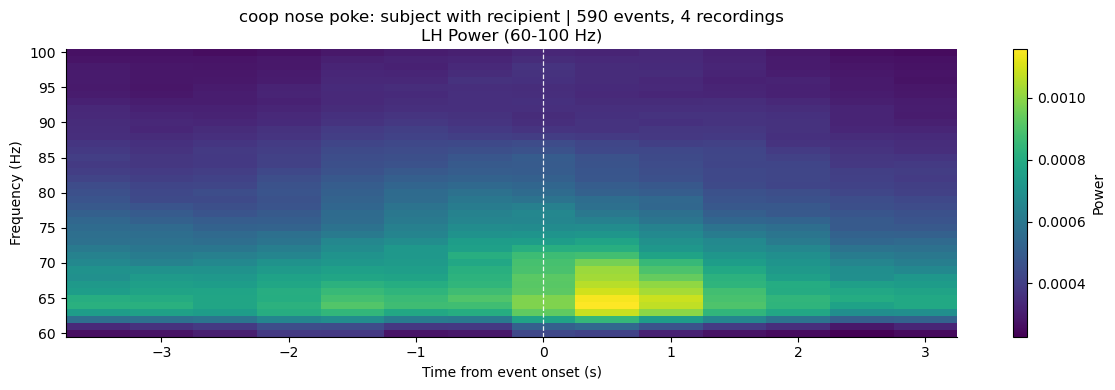

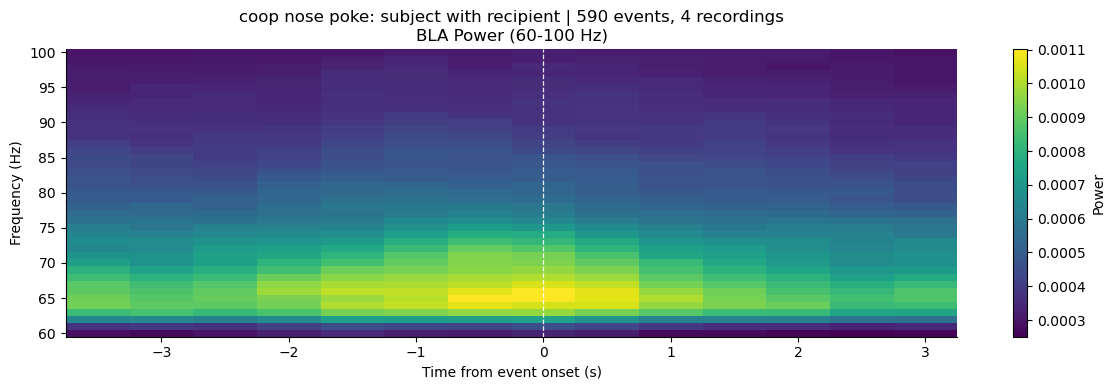

In [24]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    collection,
    event="coop nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

### High-Gamma Conditions D8

In [2]:
D8_colletion = load_lfp_collection(r"D:\PadillaCoreanoLab\Coop_Ephys\D8_lfp_collection\lfp_collection.json")

In [23]:
behavior_path = REPO_ROOT / "data" / "processed" / "stage4_thresholded" / "Stage4_D8.pkl"
d8_behaviors = load_pickle(behavior_path)
print(f"Loaded {len(d8_behaviors)} processed Day 8 behavior recordings from {behavior_path}")

Loaded 10 processed Day 8 behavior recordings from C:\Users\zhaoz\Desktop\Research\Cooperation\coop_ephys_analysis\data\processed\stage4_thresholded\Stage4_D8.pkl


In [24]:
event_update_summary = update_collection_events_from_behavior(
    D8_colletion,
    d8_behaviors,
    source_unit="seconds",
    strict=True,
)

In [25]:
print("Updated recordings:", len(event_update_summary["updated_recordings"]))
print("Unused behavior recordings:", event_update_summary["unused_behavior_recordings"])
event_update_summary["imported_events"]

Updated recordings: 10
Unused behavior recordings: []


{'20250517_105306_Stage4_D8_1-2_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'filtered coop nose pokes',
  'filtered selfish nose pokes',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250517_105306_Stage4_D8_1-3_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'filtered coop nose pokes',
  'filtered selfish nose pokes',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250517_105306_Stage4_D8_2-1_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'filtered coop nose pokes',
  'filtered selfish nose pokes',
  'recipient port entry',
  'selfish light',
  'selfish nose poke',
  'subject port entry'],
 '20250517_105306_Stage4_D8_2-4_merged.rec': ['baseline iti 2s',
  'coop light',
  'coop nose poke',
  'filtered coop nose pokes',
  'filtered selfish nose pokes',
  'recipient port entry',
  'selfish light',
  'selfish nose poke

In [27]:
condition_dict = build_condition_dict(D8_colletion)

for condition, recording_names in condition_dict.items():
    print(f"{condition}: {len(recording_names)} recordings")
    for name in recording_names:
        print("  ", name)

subject with recipient: 4 recordings
   20250517_105306_Stage4_D8_1-2_merged.rec
   20250517_105306_Stage4_D8_2-4_merged.rec
   20250517_134054_Stage4_D8_4-3_merged.rec
   20250517_134054_Stage4_D8_4-4_merged.rec
recipient: 4 recordings
   20250517_105306_Stage4_D8_1-3_merged.rec
   20250517_105306_Stage4_D8_2-1_merged.rec
   20250517_134054_Stage4_D8_4-1_merged.rec
   20250517_134054_Stage4_D8_4-2_merged.rec
subject alone: 2 recordings
   20250517_121746_Stage4_D8_6-1_merged.rec
   20250517_121746_Stage4_D8_6-3_merged.rec


In [32]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    D8_colletion,
    event="filtered selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject alone",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(60, 100),
)

ValueError: Event 'filtered selfish nose poke' has no complete windows in the selected recordings.

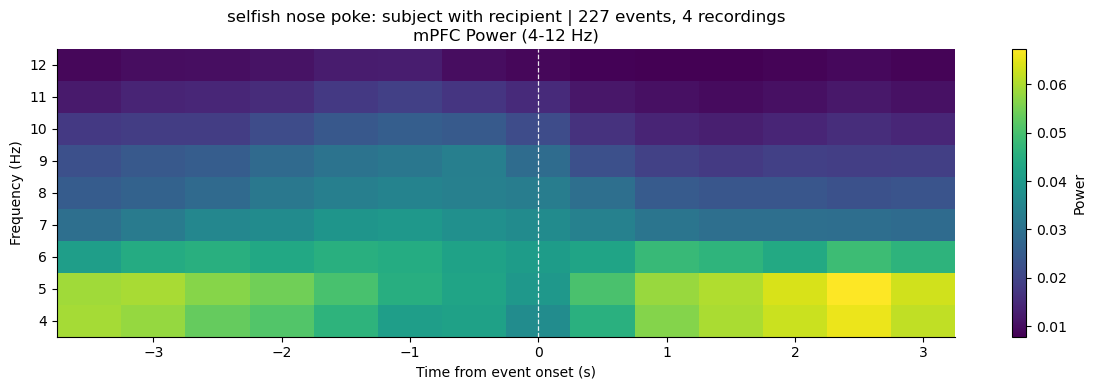

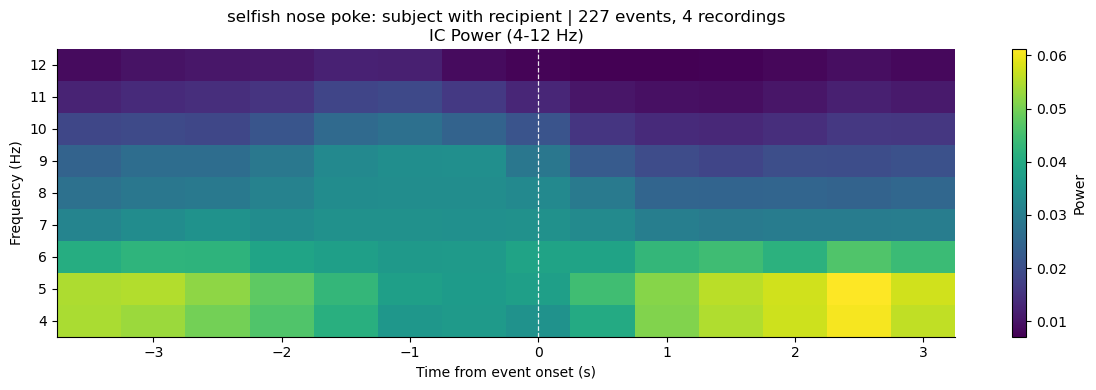

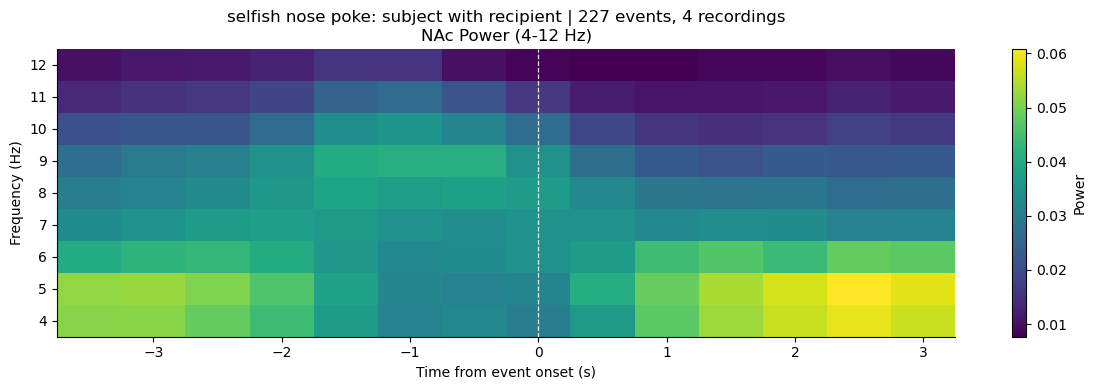

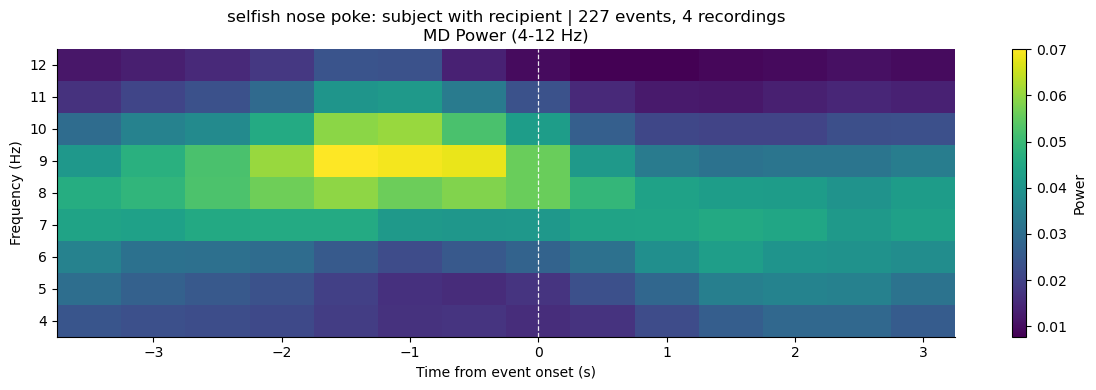

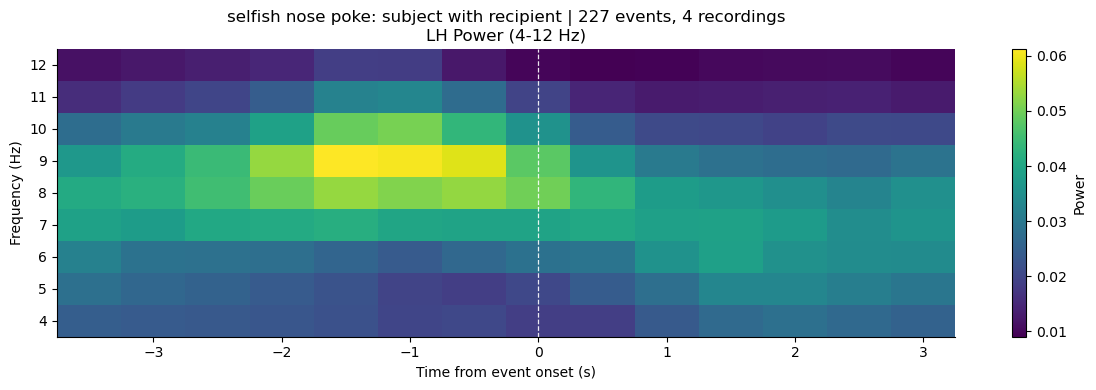

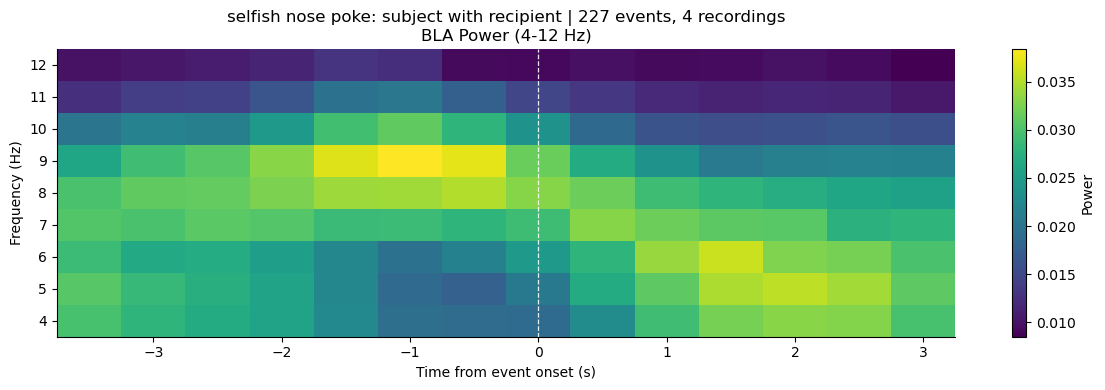

In [39]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    D8_colletion,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(4, 12),
)

### High-Gamma Social Choice D8

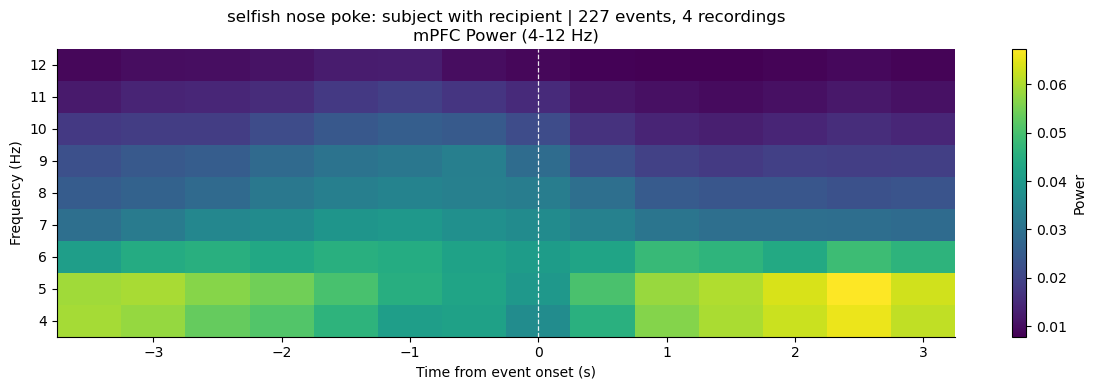

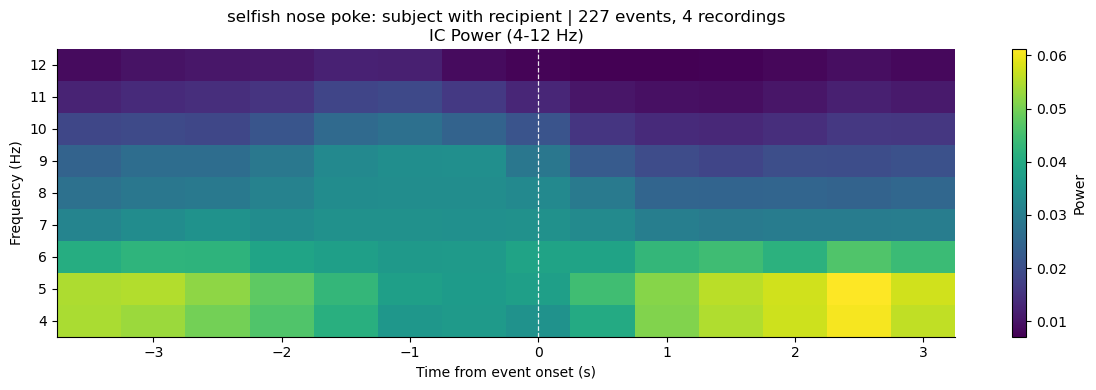

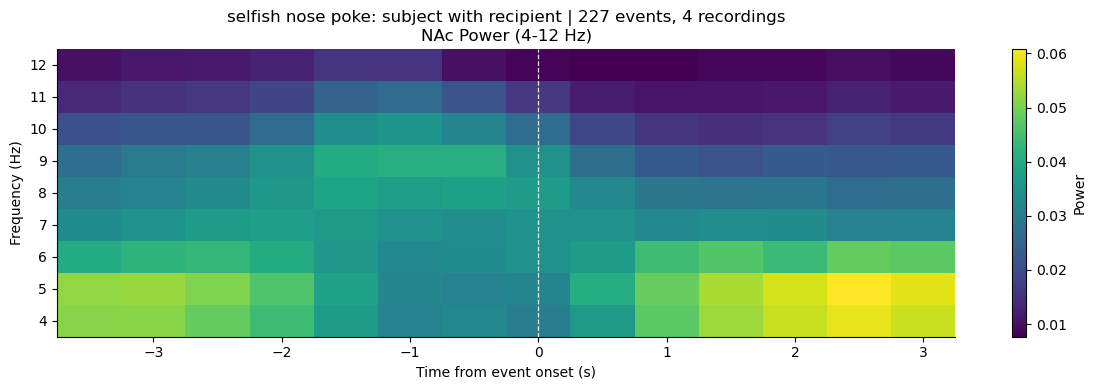

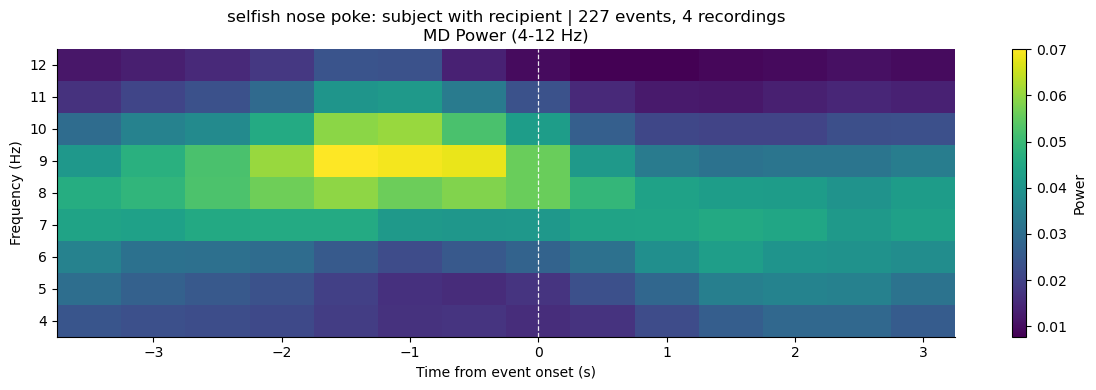

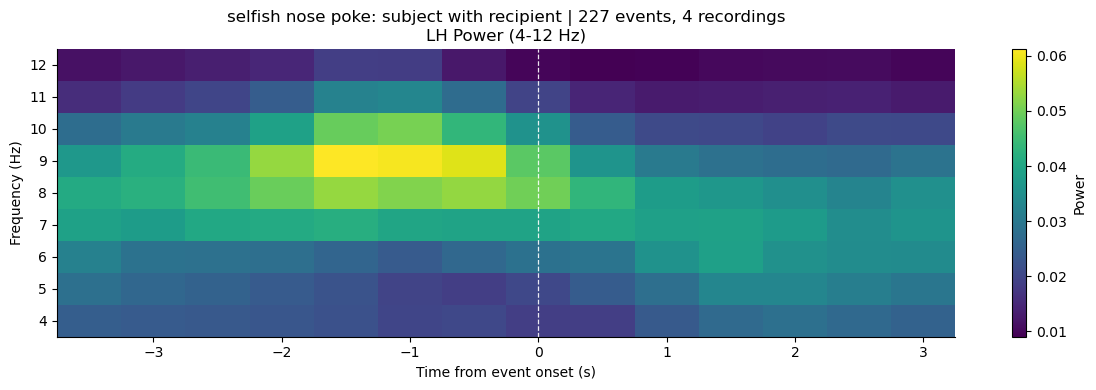

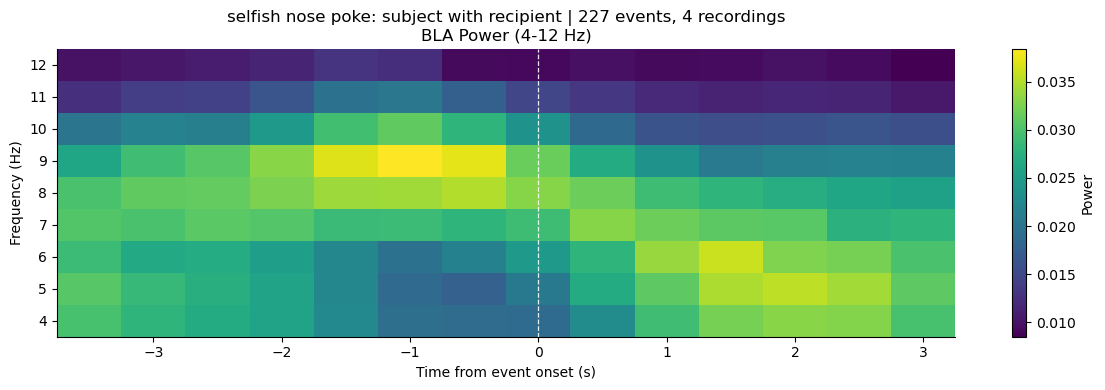

In [42]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    D8_colletion,
    event="selfish nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(4, 12),
)

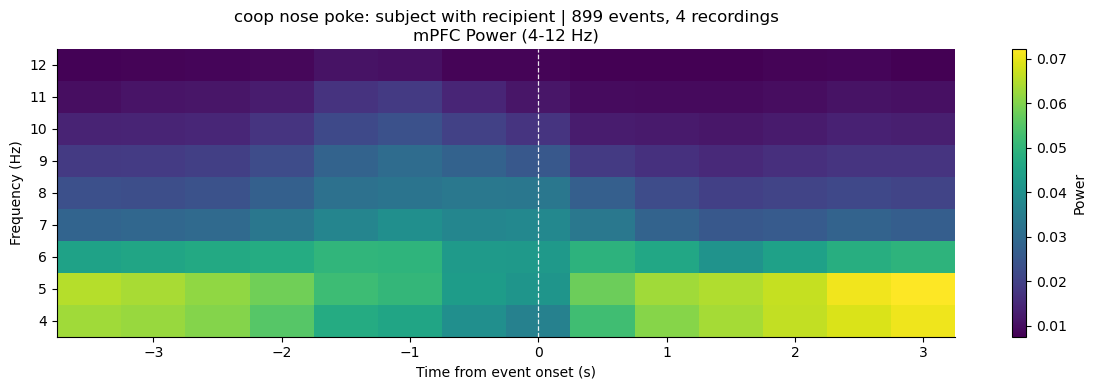

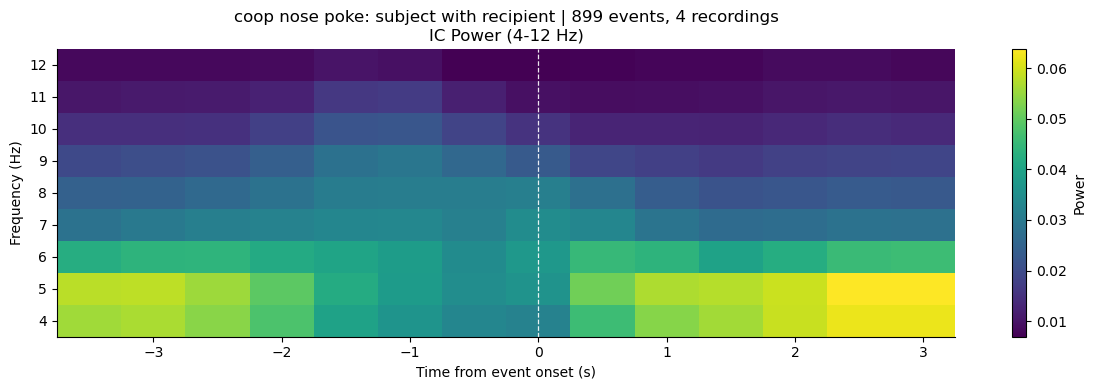

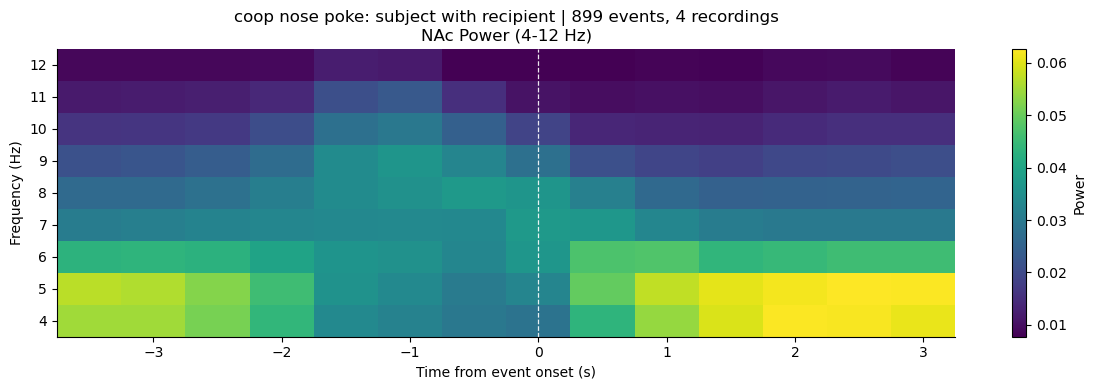

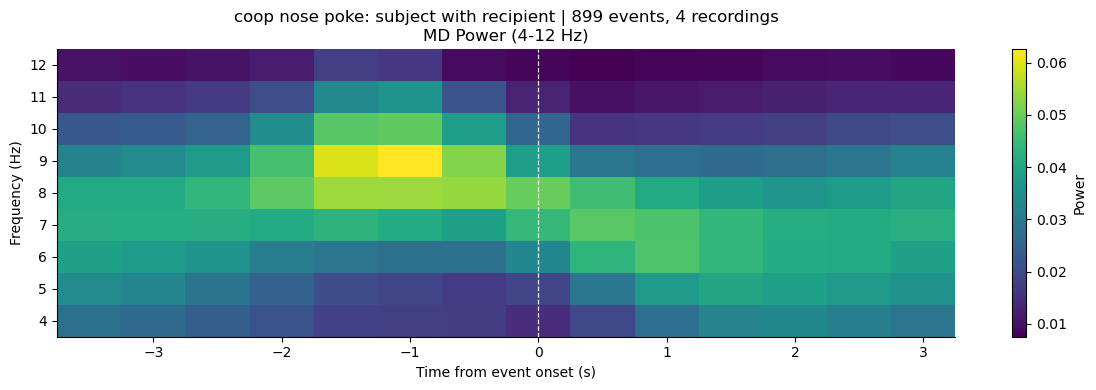

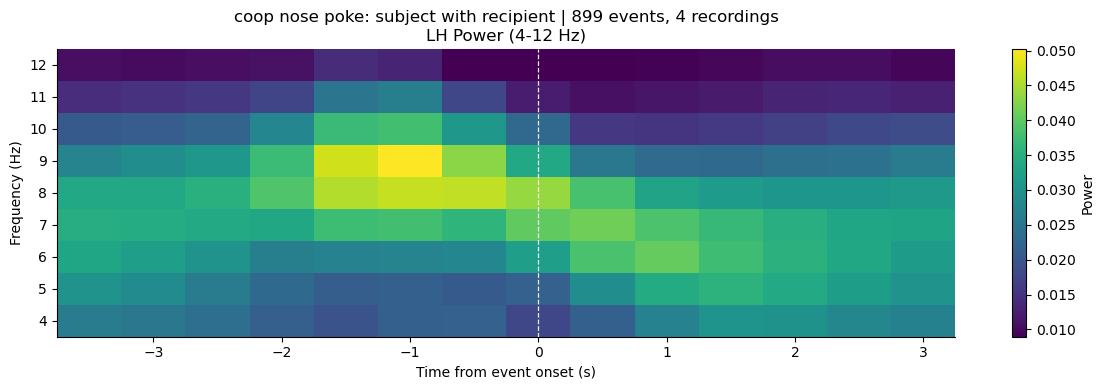

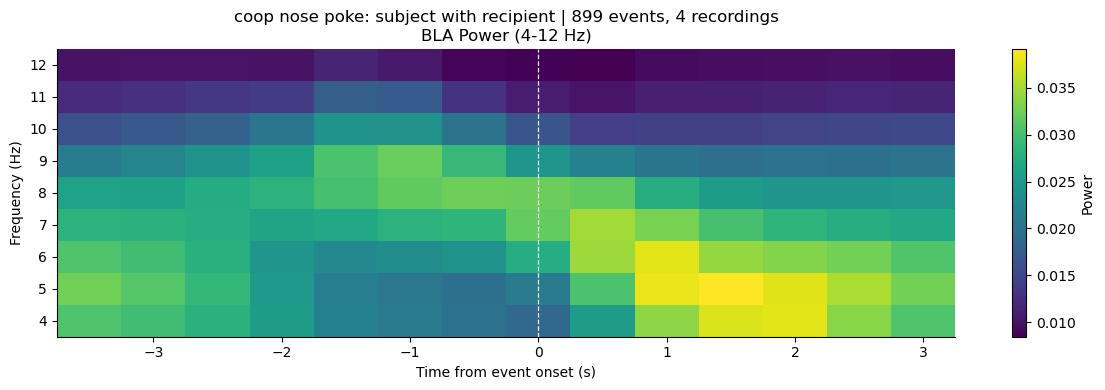

In [43]:
nose_poke_spectrogram = plot_event_average_spectrogram(
    D8_colletion,
    event="coop nose poke",
	condition_recordings=condition_dict,
	selected_condition="subject with recipient",
    mode="power",
    event_len=3.5,
    pre_window=3.5,
    post_window=0,
    freq_range=(4, 12),
)

## Baseline

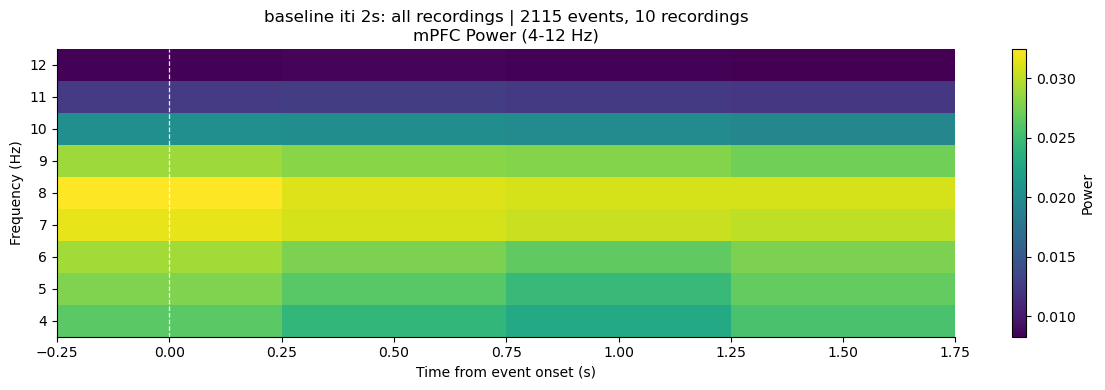

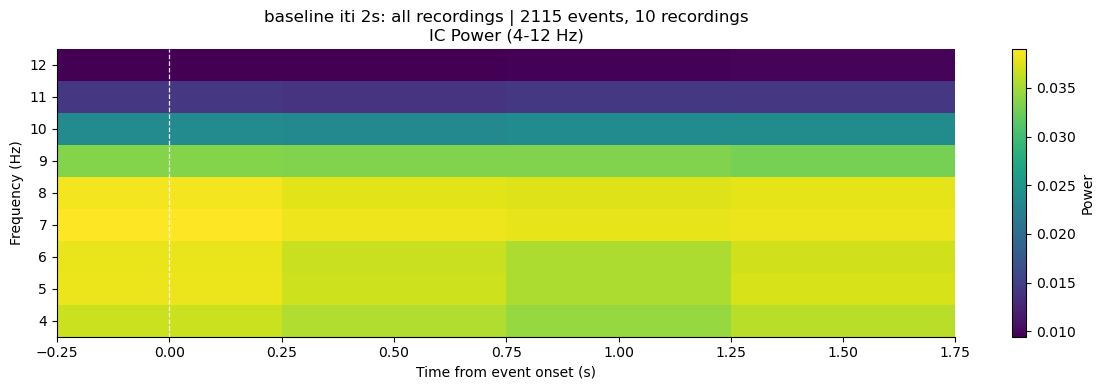

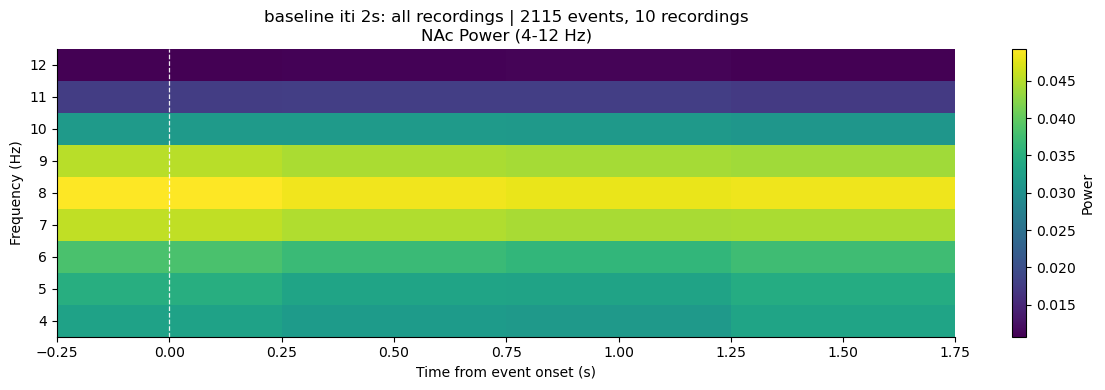

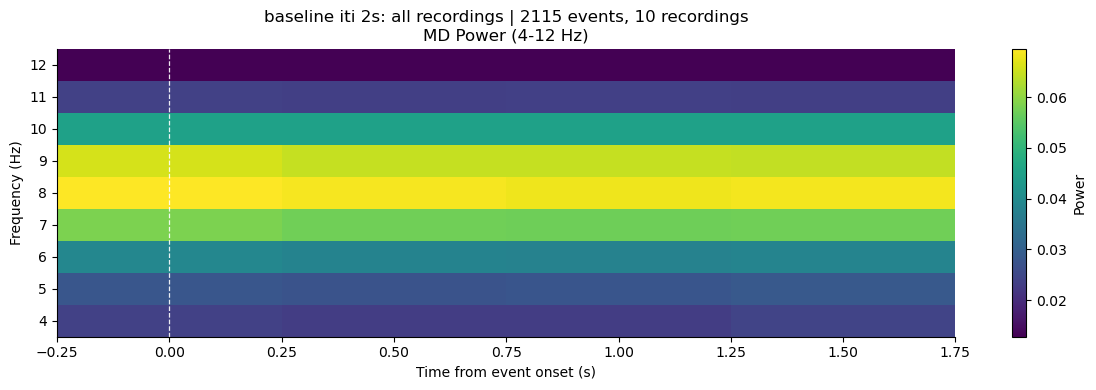

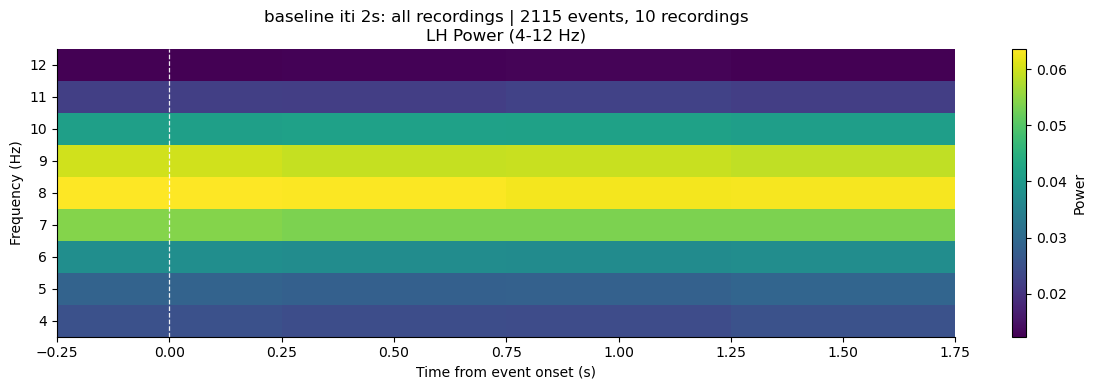

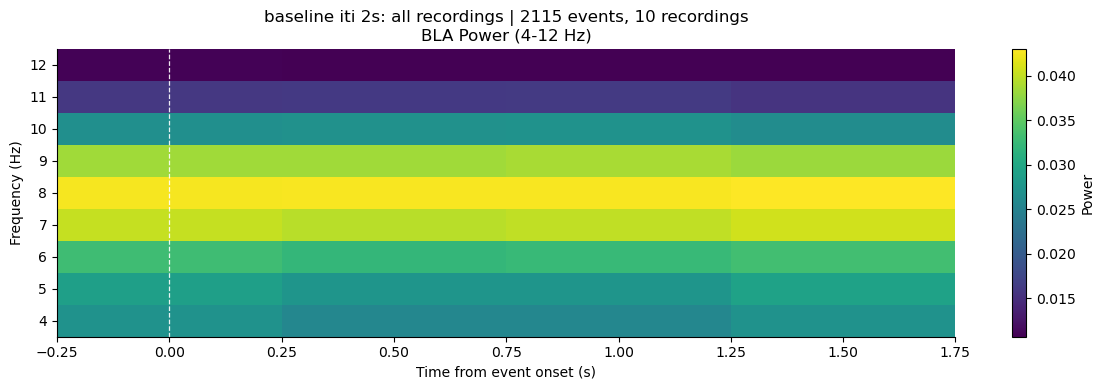

In [ ]:
baseline_iti_spectrogram = plot_event_average_spectrogram(
    collection,
    event="baseline iti 2s",
    mode="power",
    event_len=2,
    pre_window=0,
    post_window=0,
    freq_range=(4, 12),
)